In [ ]:

import torch, torchvision, PIL
import transformers, tokenizers

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("pillow:", PIL.__version__)
print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

# Dataset cleaning and split preprocessing

In [ ]:
# ============================================================
# cell-1
# FAKEDDIT IMAGE DOWNLOADER (CLEAN, RESUME-SAFE, TSV+LOG+REPORT)
# Targets: train=99.2k | val=12.4k | test=12.4k  (TOTAL=124k)
# ============================================================

import os, re, time, json, hashlib, csv
import pandas as pd
import requests
from tqdm import tqdm
from PIL import Image, ImageFile
from io import BytesIO

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -----------------------------
# INPUT TSVs (Kaggle)
# -----------------------------
TRAIN_TSV = "/kaggle/input/fakeddit-dataset/multimodal_only_samples/multimodal_train.tsv"
VAL_TSV   = "/kaggle/input/fakeddit-dataset/multimodal_only_samples/multimodal_validate.tsv"
TEST_TSV  = "/kaggle/input/fakeddit-dataset/multimodal_only_samples/multimodal_test_public.tsv"

IMAGE_COL = "image_url"
ID_COL_CANDIDATES = ["id", "post_id", "submission_id", "reddit_id"]

# -----------------------------
# OUTPUT
# -----------------------------
OUT_ROOT = "/kaggle/working/fakeddit_124k_train80_val22_test22"
os.makedirs(OUT_ROOT, exist_ok=True)

# -----------------------------
# TARGETS
# -----------------------------
TARGETS = {"train": 99200, "val": 12400, "test": 12400}
print("Targets:", TARGETS, "| Total:", sum(TARGETS.values()))

# -----------------------------
# DOWNLOAD SETTINGS
# -----------------------------
TIMEOUT = 15
MAX_RETRIES = 5
BACKOFF = 1.8
SLEEP_BETWEEN = 0.05   
VERIFY_WITH_PIL = True
JPEG_QUALITY = 95

# -----------------------------
# Helpers
# -----------------------------
def sha1_text(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8", errors="ignore")).hexdigest()

def safe_name(s: str, max_len=120) -> str:
    s = str(s)
    s = re.sub(r"[^\w\-.]+", "_", s).strip("_")
    return s[:max_len] if s else "item"

def pick_id_col(df: pd.DataFrame) -> str:
    cols = {c.lower(): c for c in df.columns}
    for cand in ID_COL_CANDIDATES:
        if cand.lower() in cols:
            return cols[cand.lower()]
    return ""

def make_filename(sample_id: str, url: str) -> str:
    sid = safe_name(sample_id)
    uhash = sha1_text(url)[:10]
    return f"{sid}__{uhash}.jpg"

def ensure_csv_header(path, header):
    if not os.path.exists(path):
        with open(path, "w", newline="", encoding="utf-8") as f:
            csv.writer(f).writerow(header)

def load_written_clean_filenames(clean_tsv_path: str) -> set:
    """
    Resume-safety: if clean.tsv already exists, we skip rows already written.
    Reads only local_image column (lightweight).
    """
    written = set()
    if os.path.exists(clean_tsv_path):
        try:
            df = pd.read_csv(clean_tsv_path, sep="\t", usecols=["local_image"])
            written = set(df["local_image"].astype(str).tolist())
        except Exception:
            written = set()
    return written

def download_bytes(session: requests.Session, url: str):
    headers = {"User-Agent": "Mozilla/5.0 (compatible; FakedditResearchDownloader/1.0)"}
    last_err = ""
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            r = session.get(url, timeout=TIMEOUT, headers=headers)
            code = r.status_code

            if code != 200:
                if code == 429 or (500 <= code <= 599):
                    time.sleep(BACKOFF * attempt)
                    continue
                return False, code, None, f"HTTP_{code}"

            content = r.content
            if not content or len(content) < 200:
                return False, code, None, "EMPTY_OR_TOO_SMALL"
            return True, code, content, ""

        except requests.exceptions.RequestException as e:
            last_err = type(e).__name__
            time.sleep(BACKOFF * attempt)
        except Exception as e:
            last_err = type(e).__name__
            time.sleep(BACKOFF * attempt)

    return False, None, None, f"FAILED_RETRIES_{last_err}"

def save_as_jpg(content: bytes, out_path: str):
    img = Image.open(BytesIO(content)).convert("RGB")
    if VERIFY_WITH_PIL:
        img.verify()
        img = Image.open(BytesIO(content)).convert("RGB")
    img.save(out_path, format="JPEG", quality=JPEG_QUALITY)

# -----------------------------
# Main downloader per split
# -----------------------------
def process_split(split: str, tsv_path: str, target_success: int):
    print(f"\n========== SPLIT: {split} (target={target_success}) ==========")

    df = pd.read_csv(tsv_path, sep="\t", low_memory=False)
    if IMAGE_COL not in df.columns:
        raise ValueError(f"'{IMAGE_COL}' not found. Columns={df.columns.tolist()}")

    id_col = pick_id_col(df)
    print(f"Rows in TSV: {len(df)} | ID col: {id_col if id_col else '(row_index)'}")

    split_dir = os.path.join(OUT_ROOT, split)
    os.makedirs(split_dir, exist_ok=True)

    log_csv   = os.path.join(OUT_ROOT, f"{split}_download_log.csv")
    clean_tsv = os.path.join(OUT_ROOT, f"{split}_clean.tsv")

    ensure_csv_header(log_csv, ["row_idx","sample_id","url","filename","status","http_code","error"])

    written_in_clean = load_written_clean_filenames(clean_tsv)

    # Resume: count existing images
    existing_files = [f for f in os.listdir(split_dir) if f.lower().endswith(".jpg")]
    ok_count = len(existing_files)
    fail_count = 0
    print(f"Resume: {ok_count} images already exist in {split_dir}")
    print(f"Resume: {len(written_in_clean)} rows already written in {clean_tsv}")

    # Incremental TSV writer
    clean_exists = os.path.exists(clean_tsv)
    clean_f = open(clean_tsv, "a", newline="", encoding="utf-8")
    w = csv.writer(clean_f, delimiter="\t")
    if not clean_exists:
        w.writerow(list(df.columns) + ["local_image"])

    session = requests.Session()
    pbar = tqdm(total=len(df), desc=f"Downloading {split}")

    for row_idx, row in df.iterrows():
        pbar.update(1)
        if ok_count >= target_success:
            break

        url = row.get(IMAGE_COL, None)
        if pd.isna(url) or not isinstance(url, str) or not url.startswith(("http://","https://")):
            continue

        sample_id = str(row[id_col]) if id_col else str(row_idx)
        filename = make_filename(sample_id, url)
        out_path = os.path.join(split_dir, filename)

        # If already in clean.tsv and file exists => done
        if filename in written_in_clean and os.path.exists(out_path):
            continue

        # If file exists but not in clean.tsv => add now (keeps TSV consistent)
        if os.path.exists(out_path) and filename not in written_in_clean:
            ok_count += 1
            with open(log_csv, "a", newline="", encoding="utf-8") as f:
                csv.writer(f).writerow([row_idx, sample_id, url, filename, "OK", 200, "EXISTING_FILE"])
            w.writerow(list(row.values) + [filename])
            written_in_clean.add(filename)
            continue

        ok, code, content, err = download_bytes(session, url)
        if ok:
            try:
                save_as_jpg(content, out_path)
                ok_count += 1
                with open(log_csv, "a", newline="", encoding="utf-8") as f:
                    csv.writer(f).writerow([row_idx, sample_id, url, filename, "OK", code, ""])
                w.writerow(list(row.values) + [filename])
                written_in_clean.add(filename)
            except Exception as e:
                fail_count += 1
                try:
                    if os.path.exists(out_path):
                        os.remove(out_path)
                except:
                    pass
                with open(log_csv, "a", newline="", encoding="utf-8") as f:
                    csv.writer(f).writerow([row_idx, sample_id, url, filename, "FAIL", code, f"PIL_SAVE_{type(e).__name__}"])
        else:
            fail_count += 1
            with open(log_csv, "a", newline="", encoding="utf-8") as f:
                csv.writer(f).writerow([row_idx, sample_id, url, filename, "FAIL", code if code else "", err])

        time.sleep(SLEEP_BETWEEN)

    pbar.close()
    clean_f.close()

    report = {
        "split": split,
        "target_success": int(target_success),
        "rows_in_tsv": int(len(df)),
        "success_images_in_folder": int(len([f for f in os.listdir(split_dir) if f.lower().endswith(".jpg")])),
        "fail_logged_this_run": int(fail_count),
        "output_dir": split_dir,
        "clean_tsv": clean_tsv,
        "log_csv": log_csv,
    }

    with open(os.path.join(OUT_ROOT, f"{split}_report.json"), "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

    return report


In [ ]:
train_report = process_split("train", TRAIN_TSV, TARGETS["train"])
val_report = process_split("val", VAL_TSV, TARGETS["val"])
test_report = process_split("test", TEST_TSV, TARGETS["test"])

In [2]:


path = "/kaggle/input/datasets/rejuyanhossainshawon/clean-csv/train_verified_99200.csv"

df = pd.read_csv(path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\n6-way label distribution:")
if "6_way_label" in df.columns:
    print(df["6_way_label"].value_counts().sort_index())

Shape: (99200, 16)

Columns:
['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']

First 5 rows:


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,WetCoastLife,are you not the law,1.478828e+09,NaN,True,d9v87n7,http://i.imgur.com/aJj0cl2.jpg,5c8b7h,0.0,5,psbattle_artwork,ARE YOU NOT THE LAW?!?!?,0.00,0,2,4
1,yellowblahblah,shifty cabinet,1.564085e+09,i.redd.it,True,chsrpx,https://preview.redd.it/333jsi8gaic31.jpg?widt...,NaN,5.0,222,pareidolia,Shifty cabinet,0.98,0,2,2
2,BecomeEthereal,sorry i took so long,1.364761e+09,NaN,True,c95vov6,http://i.imgur.com/QWAQBI5.jpg,1b921i,0.0,2,psbattle_artwork,sorry I took so long,0.00,0,2,4
3,frugalfred1,harry potter with a bowl haircut and sunglasses,1.560711e+09,i.redd.it,True,c1dbiq,https://preview.redd.it/9ad2lvrqjr431.jpg?widt...,NaN,5.0,9,mildlyinteresting,Harry Potter With a Bowl Haircut and Sunglasses,0.78,1,0,0
4,Limabean17,oh mickey,1.427637e+09,NaN,True,cpuglqo,http://i.imgur.com/WQObRrT.jpg,30nc7n,0.0,11,psbattle_artwork,Oh Mickey...,0.00,0,2,4



Data types:
author                   object
clean_title              object
created_utc             float64
domain                   object
hasImage                   bool
id                       object
image_url                object
linked_submission_id     object
num_comments            float64
score                     int64
subreddit                object
title                    object
upvote_ratio            float64
2_way_label               int64
3_way_label               int64
6_way_label               int64
dtype: object

Missing values:
author                   3956
clean_title                 0
created_utc                 0
domain                  47799
hasImage                    0
id                          0
image_url                   0
linked_submission_id    51401
num_comments                0
score                       0
subreddit                   0
title                       0
upvote_ratio                0
2_way_label                 0
3_way_label             

In [1]:
# ============================================================
#  CLEAN EXISTING HEADVALID CSVs + FILL DEFICITS FROM TSVs
# - Existing rows: HEAD check only (no download)
# - NEW rows from TSV: download small bytes + PIL.verify() (guaranteed real image)
# - Cleans: invalid URLs, duplicates, cross-split overlap (id/url/title_norm)
# - Computes deficit to reach exact sizes: 99200 / 12400 / 12400
# ============================================================

import os, re, hashlib, time, io, numpy as np, pandas as pd
import requests
from tqdm.auto import tqdm
from PIL import Image

# -----------------------------
# INPUT
# -----------------------------
CSV_TRAIN = "/kaggle/input/datasets/rejuyanhossainshawon/clean-csv/train_verified_99200.csv"
CSV_VAL   = "/kaggle/input/datasets/rejuyanhossainshawon/clean-csv/val_verified_12400.csv"
CSV_TEST  = "/kaggle/input/datasets/rejuyanhossainshawon/clean-csv/test_verified_12400.csv"

# -----------------------------
# INPUT
# -----------------------------
TSV_TRAIN = "/kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_train.tsv"
TSV_VAL   = "/kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_validate.tsv"
TSV_TEST  = "/kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_test_public.tsv"

# -----------------------------
# OUTPUT: final CSVs
# -----------------------------
OUT_DIR = "/kaggle/working"
OUT_TRAIN = os.path.join(OUT_DIR, "train_clean_filled_99200.csv")
OUT_VAL   = os.path.join(OUT_DIR, "val_clean_filled_12400.csv")
OUT_TEST  = os.path.join(OUT_DIR, "test_clean_filled_12400.csv")

# -----------------------------
# TARGET SIZES
# -----------------------------
N_TRAIN, N_VAL, N_TEST = 99200, 12400, 12400
SEED = 42

# -----------------------------
# Column config 
# -----------------------------
ID_COL    = "id"
TITLE_COL = "title"
URL_COL   = "image_url"

# -----------------------------
# Networking
# -----------------------------
TIMEOUT = 10
MAX_RETRIES = 1

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

def looks_like_http(url: str) -> bool:
    if not isinstance(url, str): return False
    url = url.strip()
    return url.startswith("http://") or url.startswith("https://")

# -----------------------------
# A) Existing rows validation 
# -----------------------------
CACHE_DIR_HEAD = "/kaggle/working/url_head_cache_fill"
os.makedirs(CACHE_DIR_HEAD, exist_ok=True)

def _cache_path_head(url: str) -> str:
    h = hashlib.sha1(url.encode("utf-8")).hexdigest()
    return os.path.join(CACHE_DIR_HEAD, f"{h}.txt")

def cache_get_head(url: str):
    p = _cache_path_head(url)
    if os.path.exists(p):
        try:
            s = open(p, "r", encoding="utf-8").read().strip()
            if s == "OK": return True
            if s == "NO": return False
        except:
            return None
    return None

def cache_put_head(url: str, ok: bool):
    try:
        with open(_cache_path_head(url), "w", encoding="utf-8") as f:
            f.write("OK" if ok else "NO")
    except:
        pass

def head_says_image(url: str) -> bool:
    url = "" if url is None else str(url).strip()
    if not looks_like_http(url):
        return False

    c = cache_get_head(url)
    if c is not None:
        return c

    ok = False
    try:
        for _ in range(MAX_RETRIES + 1):
            try:
                r = session.head(url, allow_redirects=True, timeout=TIMEOUT)
                if r.status_code != 200:
                    time.sleep(0.1)
                    continue
                ct = (r.headers.get("Content-Type") or "").lower().strip()
                if not ct.startswith("image/"):
                    time.sleep(0.1)
                    continue
                cl = r.headers.get("Content-Length")
                if cl is not None:
                    try:
                        if int(cl) <= 0:
                            time.sleep(0.1)
                            continue
                    except:
                        pass
                ok = True
                break
            except:
                time.sleep(0.1)
                continue
    finally:
        cache_put_head(url, ok)

    return ok

# -----------------------------
# B) NEW rows validation (download small bytes + PIL verify)
# -----------------------------
CACHE_DIR_PIL = "/kaggle/working/url_pilverify_cache_fill"
os.makedirs(CACHE_DIR_PIL, exist_ok=True)

MAX_BYTES = 3_000_000   # cap download per URL (3MB)
MIN_BYTES = 2_000

def _cache_path_pil(url: str) -> str:
    h = hashlib.sha1(("PIL|" + url).encode("utf-8")).hexdigest()
    return os.path.join(CACHE_DIR_PIL, f"{h}.txt")

def cache_get_pil(url: str):
    p = _cache_path_pil(url)
    if os.path.exists(p):
        try:
            s = open(p, "r", encoding="utf-8").read().strip()
            if s == "OK": return True
            if s == "NO": return False
        except:
            return None
    return None

def cache_put_pil(url: str, ok: bool):
    try:
        with open(_cache_path_pil(url), "w", encoding="utf-8") as f:
            f.write("OK" if ok else "NO")
    except:
        pass

def downloadable_and_decodable_image(url: str) -> bool:
    """
    Strong check for NEW rows:
    - GET stream up to MAX_BYTES
    - PIL open + verify
    """
    url = "" if url is None else str(url).strip()
    if not looks_like_http(url):
        return False

    c = cache_get_pil(url)
    if c is not None:
        return c

    ok = False
    try:
        for _ in range(MAX_RETRIES + 1):
            try:
                r = session.get(url, stream=True, allow_redirects=True, timeout=TIMEOUT)
                if r.status_code != 200:
                    time.sleep(0.1)
                    continue

                buf = bytearray()
                for chunk in r.iter_content(chunk_size=65536):
                    if not chunk:
                        break
                    buf.extend(chunk)
                    if len(buf) >= MAX_BYTES:
                        break

                if len(buf) < MIN_BYTES:
                    time.sleep(0.1)
                    continue

                try:
                    img = Image.open(io.BytesIO(buf))
                    img.verify()
                    ok = True
                    break
                except:
                    time.sleep(0.1)
                    continue

            except:
                time.sleep(0.1)
                continue
    finally:
        cache_put_pil(url, ok)

    return ok

# -----------------------------
# Title normalization (for strict no-overlap)
# -----------------------------
_url_re   = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
_punct_re = re.compile(r"[^a-z0-9\s]+", re.IGNORECASE)

def norm_title(x) -> str:
    x = "" if pd.isna(x) else str(x)
    x = x.strip().lower()
    x = _url_re.sub(" ", x)
    x = _punct_re.sub(" ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

# -----------------------------
# Load existing CSVs
# -----------------------------
train0 = pd.read_csv(CSV_TRAIN)
val0   = pd.read_csv(CSV_VAL)
test0  = pd.read_csv(CSV_TEST)

def prepare_df(df, name):
    for c in [ID_COL, TITLE_COL, URL_COL]:
        if c not in df.columns:
            raise ValueError(f"{name} missing required column: {c}")
    df = df.copy()
    df[ID_COL] = df[ID_COL].astype(str)
    df[TITLE_COL] = df[TITLE_COL].fillna("").astype(str)
    df[URL_COL] = df[URL_COL].fillna("").astype(str).str.strip()
    df["_title_norm"] = df[TITLE_COL].map(norm_title)
    df = df[(df[ID_COL].str.len() > 0) & (df[URL_COL].str.len() > 0) & (df["_title_norm"].str.len() > 0)].copy()
    df.reset_index(drop=True, inplace=True)
    return df

train0 = prepare_df(train0, "train_csv")
val0   = prepare_df(val0,   "val_csv")
test0  = prepare_df(test0,  "test_csv")

# -----------------------------
# 1) Clean existing CSVs
# -----------------------------
def filter_valid_urls_head(df, name):
    keep = []
    for i in tqdm(range(len(df)), desc=f"HEAD check existing {name}"):
        url = df.iloc[i][URL_COL]
        keep.append(head_says_image(url))
    out = df[np.array(keep, dtype=bool)].copy()
    out.reset_index(drop=True, inplace=True)
    return out

train1 = filter_valid_urls_head(train0, "train")
val1   = filter_valid_urls_head(val0,   "val")
test1  = filter_valid_urls_head(test0,  "test")

# -----------------------------
# 2) Remove duplicates inside each split (id/url/title_norm)
# -----------------------------
def dedup_inside(df):
    df = df.drop_duplicates(subset=[ID_COL], keep="first")
    df = df.drop_duplicates(subset=[URL_COL], keep="first")
    df = df.drop_duplicates(subset=["_title_norm"], keep="first")
    df.reset_index(drop=True, inplace=True)
    return df

train1 = dedup_inside(train1)
val1   = dedup_inside(val1)
test1  = dedup_inside(test1)

# -----------------------------
# 3) Remove cross-split overlaps 
# -----------------------------
def remove_overlap(base_df, other_df):
    base_ids    = set(base_df[ID_COL])
    base_urls   = set(base_df[URL_COL])
    base_titles = set(base_df["_title_norm"])
    mask = ~(
        other_df[ID_COL].isin(base_ids) |
        other_df[URL_COL].isin(base_urls) |
        other_df["_title_norm"].isin(base_titles)
    )
    out = other_df[mask].copy()
    out.reset_index(drop=True, inplace=True)
    return out

val1  = remove_overlap(train1, val1)
test1 = remove_overlap(train1, test1)
test1 = remove_overlap(val1, test1)

print("\nAfter cleaning existing CSVs:")
print("train:", len(train1), "val:", len(val1), "test:", len(test1))

need_train = N_TRAIN - len(train1)
need_val   = N_VAL   - len(val1)
need_test  = N_TEST  - len(test1)

print("\nDeficit to reach targets:")
print("need_train:", need_train)
print("need_val  :", need_val)
print("need_test :", need_test)

if need_train < 0 or need_val < 0 or need_test < 0:
    train1 = train1.iloc[:N_TRAIN].copy()
    val1   = val1.iloc[:N_VAL].copy()
    test1  = test1.iloc[:N_TEST].copy()
    need_train = N_TRAIN - len(train1)
    need_val   = N_VAL   - len(val1)
    need_test  = N_TEST  - len(test1)
    print("\nTrimmed oversize splits. New deficits:", need_train, need_val, need_test)

if need_train == 0 and need_val == 0 and need_test == 0:
    for d in (train1, val1, test1):
        d.drop(columns=["_title_norm"], inplace=True, errors="ignore")
    train1.to_csv(OUT_TRAIN, index=False)
    val1.to_csv(OUT_VAL, index=False)
    test1.to_csv(OUT_TEST, index=False)
    print("\n✅ Already complete. Saved filled outputs.")
    raise SystemExit

# -----------------------------
# Load TSV pool and fill ONLY missing rows
# -----------------------------
def read_tsv(path):
    return pd.read_csv(path, sep="\t", dtype=str, engine="python", on_bad_lines="skip")

tsv_pool = pd.concat([read_tsv(TSV_TRAIN), read_tsv(TSV_VAL), read_tsv(TSV_TEST)], ignore_index=True)

for c in [TITLE_COL, URL_COL]:
    if c not in tsv_pool.columns:
        raise ValueError(f"TSV pool missing required column: {c}")

# ensure id exists
if ID_COL not in tsv_pool.columns:
    tsv_pool[ID_COL] = (tsv_pool[TITLE_COL].fillna("") + "||" + tsv_pool[URL_COL].fillna("")).map(lambda x: str(abs(hash(x))))

tsv_pool[ID_COL] = tsv_pool[ID_COL].astype(str)
tsv_pool[TITLE_COL] = tsv_pool[TITLE_COL].fillna("").astype(str)
tsv_pool[URL_COL] = tsv_pool[URL_COL].fillna("").astype(str).str.strip()
tsv_pool["_title_norm"] = tsv_pool[TITLE_COL].map(norm_title)

tsv_pool = tsv_pool[(tsv_pool[ID_COL].str.len() > 0) & (tsv_pool[URL_COL].str.len() > 0) & (tsv_pool["_title_norm"].str.len() > 0)].copy()
tsv_pool = tsv_pool.drop_duplicates(subset=[ID_COL], keep="first").reset_index(drop=True)

print("\nTSV pool size after basic cleaning:", len(tsv_pool))

# global used
used_ids    = set(train1[ID_COL]) | set(val1[ID_COL]) | set(test1[ID_COL])
used_urls   = set(train1[URL_COL]) | set(val1[URL_COL]) | set(test1[URL_COL])
used_titles = set(train1["_title_norm"]) | set(val1["_title_norm"]) | set(test1["_title_norm"])

# shuffle
rng = np.random.default_rng(SEED)
order = rng.permutation(len(tsv_pool))

add_train, add_val, add_test = [], [], []
pbar = tqdm(order, total=len(order), desc="Filling from TSVs (DOWNLOAD+PIL verify for NEW rows)")

for idx in pbar:
    if need_train == 0 and need_val == 0 and need_test == 0:
        break

    row = tsv_pool.iloc[int(idx)]
    rid = row[ID_COL]
    url = row[URL_COL]
    tnm = row["_title_norm"]

    if rid in used_ids or url in used_urls or tnm in used_titles:
        continue

    # STRONG VALIDATION FOR NEW ROWS
    if not downloadable_and_decodable_image(url):
        continue

    if need_train > 0:
        add_train.append(row); need_train -= 1
    elif need_val > 0:
        add_val.append(row); need_val -= 1
    elif need_test > 0:
        add_test.append(row); need_test -= 1

    used_ids.add(rid); used_urls.add(url); used_titles.add(tnm)

    if (len(add_train) + len(add_val) + len(add_test)) % 500 == 0:
        pbar.set_postfix(add_train=len(add_train), add_val=len(add_val), add_test=len(add_test),
                         need_train=need_train, need_val=need_val, need_test=need_test)

if not (need_train == 0 and need_val == 0 and need_test == 0):
    raise RuntimeError(
        f"Could not fill all deficits from TSVs under strict rules.\n"
        f"Remaining: need_train={need_train}, need_val={need_val}, need_test={need_test}\n"
        f"Fix: increase MAX_BYTES (e.g., 5MB), increase TIMEOUT, or relax strictness (allow duplicate titles inside train)."
    )

train_final = pd.concat([train1, pd.DataFrame(add_train)], ignore_index=True)
val_final   = pd.concat([val1,   pd.DataFrame(add_val)],   ignore_index=True)
test_final  = pd.concat([test1,  pd.DataFrame(add_test)],  ignore_index=True)

for d in (train_final, val_final, test_final):
    d.drop(columns=["_title_norm"], inplace=True, errors="ignore")

assert len(train_final) == N_TRAIN and len(val_final) == N_VAL and len(test_final) == N_TEST

train_final.to_csv(OUT_TRAIN, index=False)
val_final.to_csv(OUT_VAL, index=False)
test_final.to_csv(OUT_TEST, index=False)

print("\n✅ DONE. Saved filled splits:")
print(" -", OUT_TRAIN, "rows:", len(train_final))
print(" -", OUT_VAL,   "rows:", len(val_final))
print(" -", OUT_TEST,  "rows:", len(test_final))
print("HEAD cache:", CACHE_DIR_HEAD)
print("PIL-verify cache (NEW rows):", CACHE_DIR_PIL)

HEAD check existing train:   0%|          | 0/98703 [00:00<?, ?it/s]

HEAD check existing val:   0%|          | 0/12339 [00:00<?, ?it/s]

HEAD check existing test:   0%|          | 0/12345 [00:00<?, ?it/s]


After cleaning existing CSVs:
train: 81651 val: 9884 test: 9757

Deficit to reach targets:
need_train: 17549
need_val  : 2516
need_test : 2643

TSV pool size after basic cleaning: 678730


Filling from TSVs (DOWNLOAD+PIL verify for NEW rows):   0%|          | 0/678730 [00:00<?, ?it/s]


✅ DONE. Saved filled splits:
 - /kaggle/working/train_clean_filled_99200.csv rows: 99200
 - /kaggle/working/val_clean_filled_12400.csv rows: 12400
 - /kaggle/working/test_clean_filled_12400.csv rows: 12400
HEAD cache: /kaggle/working/url_head_cache_fill
PIL-verify cache (NEW rows): /kaggle/working/url_pilverify_cache_fill


In [2]:
# ============================================================
# LEAKAGE + CONTAMINATION CHECK 
# Handles mixed int/str labels → NO TypeError
# ============================================================

import pandas as pd
import numpy as np

print("========== BASIC INFO ==========")
print("Train:", len(train_final))
print("Val  :", len(val_final))
print("Test :", len(test_final))
print()

# Column config 
ID_COL = "id"          
URL_COL = "image_url"  
TITLE_COL = "title"     
LABEL_COL = "6_way_label"


def safe_set(df, col):
    if col not in df.columns:
        print(f"Column '{col}' not found.")
        return set()
    return set(df[col].fillna("").astype(str).str.strip())

# ------------------------------------------------------------
# ID Overlap
# ------------------------------------------------------------
print("========== ID OVERLAP ==========")
train_ids = safe_set(train_final, ID_COL)
val_ids   = safe_set(val_final, ID_COL)
test_ids  = safe_set(test_final, ID_COL)

print(f"train ∩ val : {len(train_ids & val_ids)}")
print(f"train ∩ test: {len(train_ids & test_ids)}")
print(f"val   ∩ test: {len(val_ids & test_ids)}")
print()

# ------------------------------------------------------------
#  IMAGE URL Overlap 
# ------------------------------------------------------------
print("========== IMAGE URL OVERLAP ==========")
train_img = safe_set(train_final, URL_COL)
val_img   = safe_set(val_final, URL_COL)
test_img  = safe_set(test_final, URL_COL)

print(f"train ∩ val : {len(train_img & val_img)}")
print(f"train ∩ test: {len(train_img & test_img)}")
print(f"val   ∩ test: {len(val_img & test_img)}")
print()

# ------------------------------------------------------------
#  TITLE Overlap
# ------------------------------------------------------------
print("========== TITLE OVERLAP ==========")
train_title = safe_set(train_final, TITLE_COL)
val_title   = safe_set(val_final, TITLE_COL)
test_title  = safe_set(test_final, TITLE_COL)

print(f"train ∩ val : {len(train_title & val_title)}")
print(f"train ∩ test: {len(train_title & test_title)}")
print(f"val   ∩ test: {len(val_title & test_title)}")
print()

# ------------------------------------------------------------
# DUPLICATES INSIDE SPLITS
# ------------------------------------------------------------
print("========== DUPLICATES INSIDE SPLITS ==========")

def duplicate_count(df, col):
    if col not in df.columns:
        return 0
  
    return df[col].astype(str).duplicated(keep=False).sum()

for col, name in [(ID_COL, "ID"), (URL_COL, "image_url"), (TITLE_COL, "title")]:
    print(f"{name} duplicates in train: {duplicate_count(train_final, col):,}")
    print(f"{name} duplicates in val  : {duplicate_count(val_final, col):,}")
    print(f"{name} duplicates in test : {duplicate_count(test_final, col):,}")
    print()

# ------------------------------------------------------------
# SAFE Label Distribution (FIXED - handles str/int mix)
# ------------------------------------------------------------
print("========== LABEL DISTRIBUTION ==========")
if LABEL_COL in train_final.columns:
    def safe_vc(df):
        # Convert to numeric, then back to string for consistent sorting
        vc = df[LABEL_COL].astype(str).value_counts()
        return vc.sort_index(key=lambda x: pd.to_numeric(x, errors='coerce').fillna(-1))
    
    print("Train label counts:")
    print(safe_vc(train_final))
    print("\nVal label counts:")
    print(safe_vc(val_final))
    print("\nTest label counts:")
    print(safe_vc(test_final))
print()

# ------------------------------------------------------------
#  Missing Image Rate Per Class
# ------------------------------------------------------------
print("========== MISSING IMAGE RATE PER CLASS ==========")
if URL_COL in train_final.columns and LABEL_COL in train_final.columns:
    for name, df in [("Train", train_final), ("Val", val_final)]:
        df["_missing_img"] = ~df[URL_COL].astype(str).str.startswith("http")
        print(f"{name} missing image rate per class:")
        print(df.groupby(LABEL_COL)["_missing_img"].mean())
        print()
    
    # Clean up
    for df in [train_final, val_final, test_final]:
        if "_missing_img" in df.columns:
            df.drop(columns=["_missing_img"], inplace=True)

print("✅ Leakage check complete. Copy results to your paper!")

========== BASIC INFO ==========
Train: 99200
Val  : 12400
Test : 12400

========== ID OVERLAP ==========
train ∩ val : 0
train ∩ test: 0
val   ∩ test: 0

========== IMAGE URL OVERLAP ==========
train ∩ val : 0
train ∩ test: 0
val   ∩ test: 0

========== TITLE OVERLAP ==========
train ∩ val : 0
train ∩ test: 0
val   ∩ test: 0

========== DUPLICATES INSIDE SPLITS ==========
ID duplicates in train: 0
ID duplicates in val  : 0
ID duplicates in test : 0

image_url duplicates in train: 0
image_url duplicates in val  : 0
image_url duplicates in test : 0

title duplicates in train: 0
title duplicates in val  : 0
title duplicates in test : 0

========== LABEL DISTRIBUTION ==========
Train label counts:
6_way_label
0    31380
1     5202
2    18576
3     1178
4    40412
5     2452
Name: count, dtype: int64

Val label counts:
6_way_label
0    4007
1     699
2    2323
3     138
4    4947
5     286
Name: count, dtype: int64

Test label counts:
6_way_label
0    4091
1     667
2    2390
3     148
4  

In [ ]:
# NUMERICAL FEATURE OUTLIER ANALYSIS
def outlier_check(df, num_cols):
    print("========== OUTLIERS (95th percentile) ==========")
    for col in num_cols:
        if col in df.columns:
            q = df[col].quantile([0.95, 0.99])
            print(f"{col}: 95th={q[0.95]:.1f}, 99th={q[0.99]:.1f}")
outlier_check(train_df, HGR10_NUM_COLS)

# PRECOMPUTE CLIP EMBEDDINGS + METADATA 

In [4]:
# ============================================================
#  CELL 1 — PRECOMPUTE CLIP EMBEDDINGS + METADATA 
# ============================================================

import os, io, hashlib, warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import requests

import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor

warnings.filterwarnings("ignore")

# -----------------------------
# Paths
# -----------------------------
TRAIN_CSV = "/kaggle/input/datasets/rejuyanhossainshawon/clean124k-csv/train_clean_filled_99200.csv"
VAL_CSV   = "/kaggle/input/datasets/rejuyanhossainshawon/clean124k-csv/val_clean_filled_12400.csv"
TEST_CSV  = "/kaggle/input/datasets/rejuyanhossainshawon/clean124k-csv/test_clean_filled_12400.csv"

OUT_DIR   = "/kaggle/working/hgr_feat"
CACHE_DIR = "/kaggle/working/url_cache"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# -----------------------------
# Column config 
# -----------------------------
HGR10_NUM_LABELS = 6
HGR10_CLIP_NAME  = "openai/clip-vit-base-patch32"

HGR10_NUM_COLS  = ["score", "num_comments", "upvote_ratio"]
HGR10_CAT_COLS  = ["domain"]
HGR10_BOOL_COL  = "hasImage"
HGR10_TEXT_COL  = "title"
HGR10_IMG_COL   = "image_url"
HGR10_LABEL_COL = "6_way_label"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Load CSVs
# -----------------------------
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

# -----------------------------
# Ensure needed columns exist 
# -----------------------------
def ensure_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if HGR10_IMG_COL not in df.columns:
        raise ValueError(f"Missing {HGR10_IMG_COL}")
    if HGR10_LABEL_COL not in df.columns:
        raise ValueError(f"Missing {HGR10_LABEL_COL}")
    if HGR10_TEXT_COL not in df.columns:
        df[HGR10_TEXT_COL] = ""
    if HGR10_BOOL_COL not in df.columns:
        df[HGR10_BOOL_COL] = df[HGR10_IMG_COL].astype(str).str.len().gt(0).astype(int)
    for c in HGR10_NUM_COLS:
        if c not in df.columns:
            df[c] = 0.0
    for c in HGR10_CAT_COLS:
        if c not in df.columns:
            df[c] = "UNK"
    return df

train_df = ensure_columns(train_df)
val_df   = ensure_columns(val_df)
test_df  = ensure_columns(test_df)

# -----------------------------
# Numeric normalization 
# -----------------------------
def safe_float(x, default=0.0):
    try:
        if pd.isna(x): return default
        return float(x)
    except:
        return default

train_num = np.stack([
    np.array([safe_float(v) for v in train_df[c].values], dtype=np.float32)
    for c in HGR10_NUM_COLS
], axis=1)

train_num[:, 0] = np.log1p(np.maximum(train_num[:, 0], 0))  # score
train_num[:, 1] = np.log1p(np.maximum(train_num[:, 1], 0))  # num_comments

num_mean = train_num.mean(axis=0)
num_std  = train_num.std(axis=0)
num_std[num_std < 1e-6] = 1.0

def norm_numeric_from_df(df: pd.DataFrame) -> np.ndarray:
    x = np.stack([
        np.array([safe_float(v) for v in df[c].values], dtype=np.float32)
        for c in HGR10_NUM_COLS
    ], axis=1)
    x[:, 0] = np.log1p(np.maximum(x[:, 0], 0))
    x[:, 1] = np.log1p(np.maximum(x[:, 1], 0))
    x = (x - num_mean) / num_std
    return x.astype(np.float32)

# -----------------------------
# Categorical vocab
# -----------------------------
def build_vocab(series):
    vals = series.fillna("UNK").astype(str).tolist()
    return {v: i+1 for i, v in enumerate(sorted(set(vals)))}

cat_vocabs = {c: build_vocab(train_df[c]) for c in HGR10_CAT_COLS}

def cat_to_id(col, v):
    v = "UNK" if pd.isna(v) else str(v)
    return cat_vocabs[col].get(v, 0)

def cat_ids_from_df(df: pd.DataFrame) -> np.ndarray:
    if len(HGR10_CAT_COLS) == 0:
        return np.zeros((len(df), 0), dtype=np.int64)
    arr = np.stack([
        np.array([cat_to_id(c, v) for v in df[c].values], dtype=np.int64)
        for c in HGR10_CAT_COLS
    ], axis=1)
    return arr

def has_img_from_df(df: pd.DataFrame) -> np.ndarray:
    # identical semantics: float tensor 0/1
    return df[HGR10_BOOL_COL].astype(float).values.reshape(-1, 1).astype(np.float32)

# -----------------------------
# URL->cache image loader
# -----------------------------
session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})
TIMEOUT = 10

def url_cache_path(url: str) -> str:
    h = hashlib.sha1(url.encode("utf-8")).hexdigest()
    return os.path.join(CACHE_DIR, f"{h}.jpg")

def load_image(url: str) -> Image.Image:
    try:
        url = str(url).strip()
        if not (url.startswith("http://") or url.startswith("https://")):
            return Image.new("RGB", (224,224), (0,0,0))
        p = url_cache_path(url)
        if os.path.exists(p) and os.path.getsize(p) > 0:
            return Image.open(p).convert("RGB")
        r = session.get(url, timeout=TIMEOUT)
        if r.status_code != 200:
            return Image.new("RGB", (224,224), (0,0,0))
        img = Image.open(io.BytesIO(r.content)).convert("RGB")
        try:
            img.save(p, format="JPEG", quality=90, optimize=True)
        except Exception:
            pass
        return img
    except Exception:
        return Image.new("RGB", (224,224), (0,0,0))

# -----------------------------
# CLIP embedder
# -----------------------------
processor = CLIPProcessor.from_pretrained(HGR10_CLIP_NAME)
clip = CLIPModel.from_pretrained(HGR10_CLIP_NAME).to(DEVICE)
clip.eval()

@torch.no_grad()
def embed_batch(texts, images):
    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    ).to(DEVICE)
    out = clip(**inputs)
    t = F.normalize(out.text_embeds, p=2, dim=1)
    v = F.normalize(out.image_embeds, p=2, dim=1)
    return t.cpu(), v.cpu()

def precompute_split(df: pd.DataFrame, name: str, bs: int = 64):
    texts = df[HGR10_TEXT_COL].fillna("").astype(str).tolist()
    urls  = df[HGR10_IMG_COL].astype(str).tolist()
    labels = torch.tensor(df[HGR10_LABEL_COL].values, dtype=torch.long)

    num_np    = norm_numeric_from_df(df)
    has_np    = has_img_from_df(df)
    cat_np    = cat_ids_from_df(df)

    text_embs = []
    img_embs  = []

    for i in tqdm(range(0, len(df), bs), desc=f"CLIP embed {name}"):
        j = min(i + bs, len(df))
        imgs = [load_image(u) for u in urls[i:j]]
        t, v = embed_batch(texts[i:j], imgs)
        text_embs.append(t)
        img_embs.append(v)

    text_embs = torch.cat(text_embs, dim=0)
    img_embs  = torch.cat(img_embs,  dim=0)

    torch.save(text_embs, os.path.join(OUT_DIR, f"{name}_text.pt"))
    torch.save(img_embs,  os.path.join(OUT_DIR, f"{name}_image.pt"))
    torch.save(labels,    os.path.join(OUT_DIR, f"{name}_labels.pt"))

    torch.save(torch.tensor(num_np, dtype=torch.float32), os.path.join(OUT_DIR, f"{name}_num.pt"))
    torch.save(torch.tensor(has_np, dtype=torch.float32), os.path.join(OUT_DIR, f"{name}_has.pt"))
    torch.save(torch.tensor(cat_np, dtype=torch.long),    os.path.join(OUT_DIR, f"{name}_cat.pt"))

    print(f"Saved {name}:",
          text_embs.shape, img_embs.shape,
          "num", num_np.shape, "has", has_np.shape, "cat", cat_np.shape)

precompute_split(train_df, "train", bs=64)
precompute_split(val_df,   "val",   bs=64)
precompute_split(test_df,  "test",  bs=64)

print("\n✅ DONE. Features saved in:", OUT_DIR)
print("✅ Cache dir:", CACHE_DIR)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Saved train: torch.Size([99200, 512]) torch.Size([99200, 512]) num (99200, 3) has (99200, 1) cat (99200, 1)


CLIP embed val:   0%|          | 0/194 [00:00<?, ?it/s]

Saved val: torch.Size([12400, 512]) torch.Size([12400, 512]) num (12400, 3) has (12400, 1) cat (12400, 1)


CLIP embed test:   0%|          | 0/194 [00:00<?, ?it/s]

Saved test: torch.Size([12400, 512]) torch.Size([12400, 512]) num (12400, 3) has (12400, 1) cat (12400, 1)

✅ DONE. Features saved in: /kaggle/working/hgr_feat
✅ Cache dir: /kaggle/working/url_cache


In [8]:
import os, shutil
shutil.make_archive("/kaggle/working/hgr_feat", "zip", "/kaggle/working/hgr_feat")
print("Saved:", "/kaggle/working/hgr_feat.zip")

Saved: /kaggle/working/hgr_feat.zip


# H-GR+++ Model Training, Validation, and Testing

In [1]:
# ============================================================
#  CELL 2 — TRAIN/VAL/TEST (H-GR+++ SINGLE-SEED run on PRECOMPUTED FEATURES)
# ============================================================

import os, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# -----------------------------
# CONFIG 
# -----------------------------
HGR10_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HGR10_NUM_LABELS = 6
HGR10_EPOCHS     = 6

HGR10_BATCH_TRAIN = 128
HGR10_BATCH_EVAL  = 256

HGR10_GRAD_CLIP_N   = 1.0
HGR10_LR_HEAD       = 2e-4
HGR10_WEIGHT_DECAY  = 1e-4
HGR10_LABEL_SMOOTH  = 0.02

HGR10_META_HIDDEN   = 256
HGR10_EMB_DIM       = 32
HGR10_GATE_HIDDEN   = 256
HGR10_HEAD_HIDDEN   = 1024
HGR10_DROPOUT       = 0.20
HGR10_GATE_TAU      = 2.0
HGR10_GATE_LAMBDA   = 0.005
HGR10_GATE_TARGET_M = 0.6

# Column 
HGR10_NUM_COLS = ["score", "num_comments", "upvote_ratio"]
HGR10_CAT_COLS = ["domain"]

FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"

print("Device:", HGR10_DEVICE)
print("FEAT_DIR:", FEAT_DIR)

# -----------------------------
# Load tensors
# -----------------------------
def load_split(name):
    t   = torch.load(os.path.join(FEAT_DIR, f"{name}_text.pt"))
    v   = torch.load(os.path.join(FEAT_DIR, f"{name}_image.pt"))
    y   = torch.load(os.path.join(FEAT_DIR, f"{name}_labels.pt"))
    num = torch.load(os.path.join(FEAT_DIR, f"{name}_num.pt"))
    has = torch.load(os.path.join(FEAT_DIR, f"{name}_has.pt"))
    cat = torch.load(os.path.join(FEAT_DIR, f"{name}_cat.pt"))
    return t, v, y, num, has, cat

train_t, train_v, train_y, train_num, train_has, train_cat = load_split("train")
val_t,   val_v,   val_y,   val_num,   val_has,   val_cat   = load_split("val")
test_t,  test_v,  test_y,  test_num,  test_has,  test_cat  = load_split("test")

print("✅ Loaded features:")
print("Train:", train_t.shape, train_v.shape, train_num.shape, train_has.shape, train_cat.shape, train_y.shape)
print("Val  :", val_t.shape,   val_v.shape,   val_num.shape,   val_has.shape,   val_cat.shape,   val_y.shape)
print("Test :", test_t.shape,  test_v.shape,  test_num.shape,  test_has.shape,  test_cat.shape,  test_y.shape)

# -----------------------------
# Force shapes + dtypes 
# -----------------------------
def ensure_2d(x):
    return x.view(-1, 1) if x.ndim == 1 else x

train_cat = ensure_2d(train_cat).long()
val_cat   = ensure_2d(val_cat).long()
test_cat  = ensure_2d(test_cat).long()

train_has = ensure_2d(train_has).float()
val_has   = ensure_2d(val_has).float()
test_has  = ensure_2d(test_has).float()

train_num = train_num.float()
val_num   = val_num.float()
test_num  = test_num.float()

train_y = train_y.long()
val_y   = val_y.long()
test_y  = test_y.long()

# -----------------------------
# cat_sizes computed correctly 
# -----------------------------
if len(HGR10_CAT_COLS) > 0:
    C = train_cat.size(1)
    cat_sizes = []
    for i in range(C):
        mx = torch.cat([train_cat[:, i], val_cat[:, i], test_cat[:, i]]).max().item()
        cat_sizes.append(int(mx) + 1)  # ids in [0..max]
else:
    cat_sizes = []

print("✅ cat_sizes:", cat_sizes)
print("✅ cat shapes:", train_cat.shape, val_cat.shape, test_cat.shape)
print("✅ has shapes:", train_has.shape, val_has.shape, test_has.shape)

# -----------------------------
# Dataset
# -----------------------------
class HGRFeatDataset(Dataset):
    def __init__(self, t, v, y, num, has, cat):
        self.t = t
        self.v = v
        self.y = y
        self.num = num
        self.has = has
        self.cat = cat

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return {
            "t": self.t[i],
            "v": self.v[i],
            "labels": self.y[i],
            "num": self.num[i],
            "has_img": self.has[i],
            "cat_ids": self.cat[i],
        }

def collate(batch):
    t = torch.stack([b["t"] for b in batch])
    v = torch.stack([b["v"] for b in batch])
    num = torch.stack([b["num"] for b in batch]).float()
    has_img = torch.stack([b["has_img"] for b in batch]).float()
    labels = torch.stack([b["labels"] for b in batch]).long()

    if len(HGR10_CAT_COLS) > 0:
        cat_ids = torch.stack([b["cat_ids"] for b in batch]).long()
        if cat_ids.ndim == 1:
            cat_ids = cat_ids.view(-1, 1)
    else:
        cat_ids = torch.zeros((len(batch), 0), dtype=torch.long)

    return {"t": t, "v": v, "labels": labels, "num": num, "has_img": has_img, "cat_ids": cat_ids}

train_loader = DataLoader(
    HGRFeatDataset(train_t, train_v, train_y, train_num, train_has, train_cat),
    batch_size=HGR10_BATCH_TRAIN, shuffle=True, collate_fn=collate, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    HGRFeatDataset(val_t, val_v, val_y, val_num, val_has, val_cat),
    batch_size=HGR10_BATCH_EVAL, shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    HGRFeatDataset(test_t, test_v, test_y, test_num, test_has, test_cat),
    batch_size=HGR10_BATCH_EVAL, shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True
)

# -----------------------------
# H-GR+++ (fusion/gate/head) 
# -----------------------------
class HGR10_HGR_Improved_Feats(nn.Module):
    def __init__(self, num_labels=6,
                 meta_hidden=256, emb_dim=32,
                 gate_hidden=256, head_hidden=1024,
                 dropout=0.20, gate_tau=2.0):
        super().__init__()
        self.gate_tau = gate_tau

        d = train_t.size(1)      # 512
        clip_dim = 2 * d         # 1024

        # cat embeddings 
        self.cat_embs = nn.ModuleList([
            nn.Embedding(cat_sizes[i], emb_dim) for i in range(len(HGR10_CAT_COLS))
        ])

        self.clip_compress = nn.Sequential(
            nn.Linear(clip_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        meta_in = len(HGR10_NUM_COLS) + 1 + len(HGR10_CAT_COLS) * emb_dim + 128
        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_in, meta_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.fused_dim = clip_dim + meta_hidden

        self.gate_logits = nn.Sequential(
            nn.Linear(meta_hidden, gate_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gate_hidden, self.fused_dim)
        )

        self.head = nn.Sequential(
            nn.Linear(self.fused_dim, head_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, num_labels)
        )

    def forward(self, t, v, num, has_img, cat_ids, return_gate=False):
        t = F.normalize(t, p=2, dim=1)
        v = F.normalize(v, p=2, dim=1)
        z_clip = torch.cat([t, v], dim=1)

        z_clip_comp = self.clip_compress(z_clip)

        if len(HGR10_CAT_COLS) > 0:
            cat = torch.cat([emb(cat_ids[:, i]) for i, emb in enumerate(self.cat_embs)], dim=1)
        else:
            cat = torch.empty((num.size(0), 0), device=num.device)

        meta_in = torch.cat([num, has_img, cat, z_clip_comp], dim=1)
        meta = self.meta_mlp(meta_in)

        z0 = torch.cat([z_clip, meta], dim=1)

        gl = self.gate_logits(meta)
        gate = torch.sigmoid(gl / self.gate_tau)

        z = z0 + z0 * (gate - 0.5)  # centered gated residual
        logits = self.head(z)

        if return_gate:
            return logits, gate
        return logits

model = HGR10_HGR_Improved_Feats(
    num_labels=HGR10_NUM_LABELS,
    meta_hidden=HGR10_META_HIDDEN,
    emb_dim=HGR10_EMB_DIM,
    gate_hidden=HGR10_GATE_HIDDEN,
    head_hidden=HGR10_HEAD_HIDDEN,
    dropout=HGR10_DROPOUT,
    gate_tau=HGR10_GATE_TAU
).to(HGR10_DEVICE)

# -----------------------------
# Loss: Label smoothing + class weights
# -----------------------------
class HGR10_LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=HGR10_LABEL_SMOOTH, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        n_classes = logits.size(-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            if self.weight is not None:
                true_dist = true_dist * self.weight.view(1, -1)
                true_dist = true_dist / true_dist.sum(dim=1, keepdim=True)
        return -(true_dist * log_probs).sum(dim=1).mean()

counts = torch.bincount(train_y, minlength=HGR10_NUM_LABELS).cpu().numpy()
w = counts.sum() / (HGR10_NUM_LABELS * np.maximum(counts, 1))
class_weights = torch.tensor(w, dtype=torch.float, device=HGR10_DEVICE)
ce_loss = HGR10_LabelSmoothingCE(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=HGR10_LR_HEAD, weight_decay=HGR10_WEIGHT_DECAY)

# -----------------------------
# Eval
# -----------------------------
@torch.no_grad()
def eval_model(m, loader):
    m.eval()
    yp, yt = [], []
    for b in loader:
        logits = m(
            b["t"].to(HGR10_DEVICE),
            b["v"].to(HGR10_DEVICE),
            b["num"].to(HGR10_DEVICE),
            b["has_img"].to(HGR10_DEVICE),
            b["cat_ids"].to(HGR10_DEVICE),
        )
        yp.append(logits.argmax(1).cpu())
        yt.append(b["labels"].cpu())
    y_pred = torch.cat(yp).numpy()
    y_true = torch.cat(yt).numpy()
    return (
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
        y_true, y_pred
    )

# -----------------------------
# Train (gate regularization)
# -----------------------------
best_val_macro = -1.0
best_state = None

for epoch in range(HGR10_EPOCHS):
    model.train()
    total_loss = 0.0
    gate_means = []

    for b in train_loader:
        logits, gate = model(
            b["t"].to(HGR10_DEVICE),
            b["v"].to(HGR10_DEVICE),
            b["num"].to(HGR10_DEVICE),
            b["has_img"].to(HGR10_DEVICE),
            b["cat_ids"].to(HGR10_DEVICE),
            return_gate=True
        )
        labels = b["labels"].to(HGR10_DEVICE)

        loss = ce_loss(logits, labels)
        gmean = gate.mean()
        loss = loss + HGR10_GATE_LAMBDA * (gmean - HGR10_GATE_TARGET_M).abs()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), HGR10_GRAD_CLIP_N)
        optimizer.step()

        total_loss += float(loss.item())
        gate_means.append(float(gmean.detach().item()))

    val_acc, val_macro, val_wf1, _, _ = eval_model(model, val_loader)
    print(f"Epoch {epoch+1}/{HGR10_EPOCHS} | "
          f"train_loss={total_loss/len(train_loader):.4f} | "
          f"val_acc={val_acc:.4f} | "
          f"val_macroF1={val_macro:.4f} | "
          f"val_weightedF1={val_wf1:.4f} | "
          f"gate_mean(train)={float(np.mean(gate_means)):.3f}")

    if val_macro > best_val_macro:
        best_val_macro = val_macro
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

# -----------------------------
# TEST
# -----------------------------
test_acc, test_macro, test_wf1, y_true, y_pred = eval_model(model, test_loader)

print("\n=== TEST (IDENTICAL H-GR+++ on precomputed CLIP) ===")
print(f"Acc: {test_acc:.4f}")
print(f"Macro-F1: {test_macro:.4f}")
print(f"Weighted-F1: {test_wf1:.4f}\n")

print("=== Per-class report (TEST) ===")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

print("=== Confusion matrix (TEST) ===")
print(confusion_matrix(y_true, y_pred))

# -----------------------------
# SANITY CHECK
# -----------------------------
rng = np.random.default_rng(0)
y_shuf = rng.permutation(y_true)
print("\n=== SANITY CHECK (should drop a lot) ===")
print("Macro-F1 real: ", f1_score(y_true, y_pred, average="macro"))
print("Macro-F1 shuf: ", f1_score(y_shuf, y_pred, average="macro"))

# -----------------------------
# Save best checkpoint
# -----------------------------
CKPT_OUT = "/kaggle/working/hgr_feats_best.pth"
torch.save(model.state_dict(), CKPT_OUT)
print("\n✅ Saved checkpoint:", CKPT_OUT)

Device: cuda
FEAT_DIR: /kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features
✅ Loaded features:
Train: torch.Size([99200, 512]) torch.Size([99200, 512]) torch.Size([99200, 3]) torch.Size([99200, 1]) torch.Size([99200, 1]) torch.Size([99200])
Val  : torch.Size([12400, 512]) torch.Size([12400, 512]) torch.Size([12400, 3]) torch.Size([12400, 1]) torch.Size([12400, 1]) torch.Size([12400])
Test : torch.Size([12400, 512]) torch.Size([12400, 512]) torch.Size([12400, 3]) torch.Size([12400, 1]) torch.Size([12400, 1]) torch.Size([12400])
✅ cat_sizes: [1620]
✅ cat shapes: torch.Size([99200, 1]) torch.Size([12400, 1]) torch.Size([12400, 1])
✅ has shapes: torch.Size([99200, 1]) torch.Size([12400, 1]) torch.Size([12400, 1])
Epoch 1/6 | train_loss=0.7900 | val_acc=0.9501 | val_macroF1=0.8478 | val_weightedF1=0.9479 | gate_mean(train)=0.704
Epoch 2/6 | train_loss=0.6978 | val_acc=0.9591 | val_macroF1=0.9176 | val_weightedF1=0.9590 | gate_mean(train)=0.619
Epoch 3/6 | train_loss=0.

# FIGURES for SINGLE-SEED H-GR+++ TEST

Computed arrays:
HGR_y_true: (12400,) HGR_y_pred: (12400,) HGR_y_prob: (12400, 6)


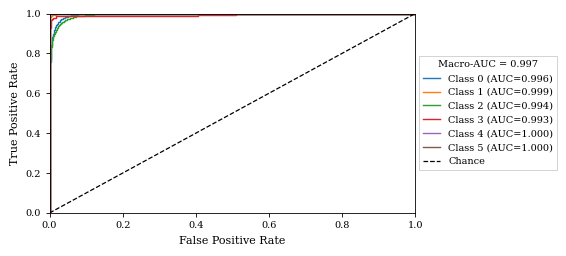

Saved: HGR_ROC_T.pdf / .png


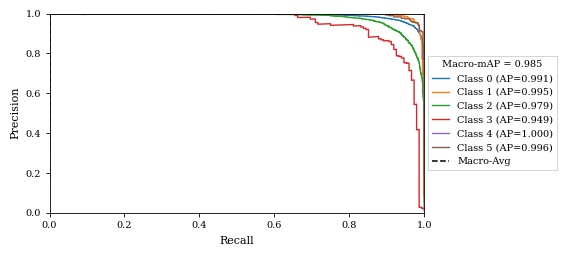

Saved: HGR_PR_T.pdf / .png


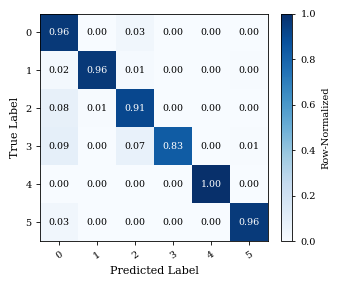

Saved: HGR_CM_T.pdf / .png


In [2]:
# ============================================================
# FIGURES for SINGLE-SEED H-GR+++ TEST
# ============================================================

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix
)

# -----------------------
# FIGURE LAYOUT

SINGLE_W = 3.5
DOUBLE_W = 7.16

USE_DOUBLE_COLUMN = True  
OUT_PREFIX = "HGR"         
DPI = 600

W = DOUBLE_W if USE_DOUBLE_COLUMN else SINGLE_W


mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,

    "axes.linewidth": 0.6,
    "lines.linewidth": 1.0,

    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def ieee_axes(ax):
    ax.grid(False)
    ax.tick_params(direction="out", length=2.6, width=0.6)
    for s in ax.spines.values():
        s.set_linewidth(0.6)

def legend_outside(ax, title=None):
    leg = ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        borderaxespad=0.0,
        frameon=True,
        fancybox=False,
        framealpha=1.0,
        handlelength=1.8,
        title=title
    )
    leg.get_frame().set_linewidth(0.6)
    if title is not None and leg.get_title() is not None:
        leg.get_title().set_fontsize(7)
    return leg

def one_hot(y, k):
    Y = np.zeros((len(y), k), dtype=int)
    Y[np.arange(len(y)), y] = 1
    return Y

def save(fig, base):
    fig.savefig(f"{base}.pdf", bbox_inches="tight", pad_inches=0.01)
    fig.savefig(f"{base}.png", dpi=DPI, bbox_inches="tight", pad_inches=0.01)


model.eval()

HGR_probs = []
HGR_preds = []
HGR_trues = []

with torch.no_grad():
    for b in test_loader:
        logits = model(
            b["t"].to(HGR10_DEVICE),
            b["v"].to(HGR10_DEVICE),
            b["num"].to(HGR10_DEVICE),
            b["has_img"].to(HGR10_DEVICE),
            b["cat_ids"].to(HGR10_DEVICE),
        )
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        pred = prob.argmax(axis=1)

        HGR_probs.append(prob)
        HGR_preds.append(pred)
        HGR_trues.append(b["labels"].cpu().numpy())

HGR_y_true = np.concatenate(HGR_trues).astype(int)
HGR_y_pred = np.concatenate(HGR_preds).astype(int)
HGR_y_prob = np.concatenate(HGR_probs).astype(float)

K = int(HGR_y_prob.shape[1])
assert K == int(HGR10_NUM_LABELS), f"K={K} but HGR10_NUM_LABELS={HGR10_NUM_LABELS}"

Y = one_hot(HGR_y_true, K)
class_labels = [f"Class {i}" for i in range(K)]

print("Computed arrays:")
print("HGR_y_true:", HGR_y_true.shape, "HGR_y_pred:", HGR_y_pred.shape, "HGR_y_prob:", HGR_y_prob.shape)

# ============================================================
# 1) ROC CURVES 
# ============================================================
fig, ax = plt.subplots(figsize=(W, 2.6))
ieee_axes(ax)

for c in range(K):
    fpr, tpr, _ = roc_curve(Y[:, c], HGR_y_prob[:, c])
    auc_c = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=1.0, label=f"{class_labels[c]} (AUC={auc_c:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.9, color="black", label="Chance")

macro_auc = float(roc_auc_score(Y, HGR_y_prob, average="macro", multi_class="ovr"))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

legend_outside(ax, title=f"Macro-AUC = {macro_auc:.3f}")

fig.tight_layout(rect=[0.0, 0.0, 0.80, 1.0])
save(fig, f"{OUT_PREFIX}_ROC_T")
plt.show()
print(f"Saved: {OUT_PREFIX}_ROC_T.pdf / .png")

# ============================================================
# 2) PR CURVES 
# ============================================================
fig, ax = plt.subplots(figsize=(W, 2.6))
ieee_axes(ax)

aps = []
rec_grid = np.linspace(0.0, 1.0, 800)
prec_interp = []

for c in range(K):
    prec, rec, _ = precision_recall_curve(Y[:, c], HGR_y_prob[:, c])
    ap = average_precision_score(Y[:, c], HGR_y_prob[:, c])
    aps.append(ap)

    ax.plot(rec, prec, linewidth=1.0, label=f"{class_labels[c]} (AP={ap:.3f})")


    prec_i = np.interp(rec_grid, rec, prec)
    prec_interp.append(prec_i)

macro_prec = np.mean(np.stack(prec_interp, axis=0), axis=0)
macro_map = float(np.mean(aps))

ax.plot(rec_grid, macro_prec, linewidth=1.1, linestyle="--", color="black", label="Macro-Avg")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

legend_outside(ax, title=f"Macro-mAP = {macro_map:.3f}")

fig.tight_layout(rect=[0.0, 0.0, 0.80, 1.0])
save(fig, f"{OUT_PREFIX}_PR_T")
plt.show()
print(f"Saved: {OUT_PREFIX}_PR_T.pdf / .png")

# ============================================================
# 3) CONFUSION MATRIX (Row-Normalized) 
# ============================================================
fig, ax = plt.subplots(figsize=(W, 2.9))
ieee_axes(ax)

cm = confusion_matrix(HGR_y_true, HGR_y_pred, labels=np.arange(K))
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1.0)

im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")

ax.set_xticks(np.arange(K))
ax.set_yticks(np.arange(K))

ax.set_xticklabels([f"{i}" for i in range(K)], rotation=35, ha="right", rotation_mode="anchor")
ax.set_yticklabels([f"{i}" for i in range(K)])

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

for i in range(K):
    for j in range(K):
        v = cm_norm[i, j]
        txt_color = "white" if v >= 0.55 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.8, color=txt_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Row-Normalized", fontsize=7)
cbar.ax.tick_params(labelsize=7, width=0.6, length=2.4)
cbar.outline.set_linewidth(0.6)

fig.tight_layout()
save(fig, f"{OUT_PREFIX}_CM_T")
plt.show()
print(f"Saved: {OUT_PREFIX}_CM_T.pdf / .png")

# 5-SEED FEATURE-ONLY ABLATION 

In [26]:
# ============================================================
#  5-SEED FEATURE-ONLY ABLATION 
# - Trains FEATURE-ONLY baseline + single-factor ablations 
# ============================================================

import os, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
import warnings; warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEEDS = [11, 22, 33, 44, 55]
EPOCHS = 6
BATCH_TRAIN, BATCH_EVAL = 128, 256

NUM_LABELS = 6
D_CLIP = 512
CLIP_DIM = 2 * D_CLIP  # 1024

# HGR hyperparams 
META_HIDDEN, EMB_DIM, GATE_HIDDEN, HEAD_HIDDEN = 256, 32, 256, 1024
DROPOUT, GATE_TAU = 0.20, 2.0
GATE_LAMBDA, GATE_TARGET_M = 0.005, 0.6

LR = 2e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_N = 1.0
LABEL_SMOOTH = 0.02

# Expect these feature tensors:
required = [
    "train_text.pt","train_image.pt","train_labels.pt","train_num.pt","train_has.pt","train_cat.pt",
    "val_text.pt","val_image.pt","val_labels.pt","val_num.pt","val_has.pt","val_cat.pt",
    "test_text.pt","test_image.pt","test_labels.pt","test_num.pt","test_has.pt","test_cat.pt",
]
missing = [f for f in required if not os.path.exists(os.path.join(FEAT_DIR, f))]
if missing:
    raise FileNotFoundError(f"Missing feature files in {FEAT_DIR}: {missing}")

print(f"✅ FEAT_DIR: {FEAT_DIR}")
print(f"✅ DEVICE: {DEVICE}")
print(f"✅ SEEDS: {SEEDS}")

# ---------------- REPRO ----------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ---------------- LOAD FEATURES ----------------
def load_split(name):
    t   = torch.load(f"{FEAT_DIR}/{name}_text.pt",   map_location="cpu")
    v   = torch.load(f"{FEAT_DIR}/{name}_image.pt",  map_location="cpu")
    y   = torch.load(f"{FEAT_DIR}/{name}_labels.pt", map_location="cpu").long()
    num = torch.load(f"{FEAT_DIR}/{name}_num.pt",    map_location="cpu").float()
    has = torch.load(f"{FEAT_DIR}/{name}_has.pt",    map_location="cpu").float()
    cat = torch.load(f"{FEAT_DIR}/{name}_cat.pt",    map_location="cpu").long()
    return t, v, y, num, has, cat

train_t, train_v, train_y, train_num, train_has, train_cat = load_split("train")
val_t,   val_v,   val_y,   val_num,   val_has,   val_cat   = load_split("val")
test_t,  test_v,  test_y,  test_num,  test_has,  test_cat  = load_split("test")

# Safety checks
assert train_t.shape[1] == D_CLIP and train_v.shape[1] == D_CLIP, "Expected 512-d text/image embeddings."

if train_has.ndim == 1: train_has = train_has.view(-1, 1)
if val_has.ndim == 1:   val_has   = val_has.view(-1, 1)
if test_has.ndim == 1:  test_has  = test_has.view(-1, 1)
if train_cat.ndim == 1: train_cat = train_cat.view(-1, 1)
if val_cat.ndim == 1:   val_cat   = val_cat.view(-1, 1)
if test_cat.ndim == 1:  test_cat  = test_cat.view(-1, 1)

assert train_num.ndim == 2 and train_has.ndim == 2 and train_cat.ndim == 2, "Expected num/has/cat to be 2D tensors."

NUM_COLS = train_num.shape[1]
CAT_COLS = train_cat.shape[1]

# Cat vocab sizes (SAFE: max over ALL splits) — ids in [0..max]
cat_sizes = []
for i in range(CAT_COLS):
    mx = torch.max(torch.stack([
        train_cat[:, i].max(),
        val_cat[:, i].max(),
        test_cat[:, i].max()
    ])).item()
    cat_sizes.append(int(mx) + 1)

print(f"✅ Shapes: train_t={tuple(train_t.shape)}, train_num={tuple(train_num.shape)}, train_has={tuple(train_has.shape)}, train_cat={tuple(train_cat.shape)}")
print(f"✅ CAT sizes: {cat_sizes if CAT_COLS>0 else 'None'}")

# ---------------- DATASET/LOADERS ----------------
class FeatDS(Dataset):
    def __init__(self, t, v, y, num, has, cat):
        self.t, self.v, self.y, self.num, self.has, self.cat = t, v, y, num, has, cat
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return {
            "t": self.t[i],
            "v": self.v[i],
            "labels": self.y[i],
            "num": self.num[i],
            "has_img": self.has[i],
            "cat_ids": self.cat[i],
        }

def collate(batch):
    t = torch.stack([b["t"] for b in batch])
    v = torch.stack([b["v"] for b in batch])
    labels = torch.stack([b["labels"] for b in batch]).long()
    num = torch.stack([b["num"] for b in batch]).float()
    has_img = torch.stack([b["has_img"] for b in batch]).float()
    cat_ids = torch.stack([b["cat_ids"] for b in batch]).long()
    if cat_ids.ndim == 1:
        cat_ids = cat_ids.view(-1, 1)
    if has_img.ndim == 1:
        has_img = has_img.view(-1, 1)
    return {"t": t, "v": v, "labels": labels, "num": num, "has_img": has_img, "cat_ids": cat_ids}

def make_loaders(seed: int):
    g = torch.Generator()
    g.manual_seed(seed)
    tr = DataLoader(
        FeatDS(train_t, train_v, train_y, train_num, train_has, train_cat),
        batch_size=BATCH_TRAIN, shuffle=True, generator=g, collate_fn=collate,
        num_workers=2, pin_memory=True
    )
    va = DataLoader(
        FeatDS(val_t, val_v, val_y, val_num, val_has, val_cat),
        batch_size=BATCH_EVAL, shuffle=False, collate_fn=collate,
        num_workers=2, pin_memory=True
    )
    te = DataLoader(
        FeatDS(test_t, test_v, test_y, test_num, test_has, test_cat),
        batch_size=BATCH_EVAL, shuffle=False, collate_fn=collate,
        num_workers=2, pin_memory=True
    )
    return tr, va, te

# ---------------- LOSS ----------------
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.02, weight=None):
        super().__init__()
        self.smoothing = float(smoothing)
        self.weight = weight  

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        n_classes = logits.size(-1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            if self.weight is not None:
                true_dist = true_dist * self.weight.view(1, -1)
                true_dist = true_dist / true_dist.sum(dim=1, keepdim=True)

        return -(true_dist * log_probs).sum(dim=1).mean()

# Class weights from TRAIN split labels
counts = torch.bincount(train_y, minlength=NUM_LABELS).cpu().numpy()
w = counts.sum() / (NUM_LABELS * np.maximum(counts, 1))
class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
ce_loss = LabelSmoothingCE(smoothing=LABEL_SMOOTH, weight=class_weights)

# ---------------- MODEL ----------------
class HGR_Feats(nn.Module):
    """
    Feature-only version of your HGR:
      t,v -> normalize -> z_clip (1024)
      z_clip_comp (128)
      meta_in:
        FULL_feat: [num, has_img, cat_emb, z_clip_comp]
        NO_STRUCT_META: [z_clip_comp] (removes num/has/cat; keeps clip context)
      meta_mlp -> meta (256)
      z0 = [z_clip, meta]  (1280)
      gating:
        FULL/NO_STRUCT_META/SMALL_HEAD: gate(meta) -> centered residual
        NO_GATING: NO gate params , z=z0
      head:
        FULL_feat / NO_STRUCT_META / NO_GATING: 1280->1024->6
        SMALL_HEAD: 1280->256->6
    """
    def __init__(self, variant="FULL_feat"):
        super().__init__()
        self.variant = variant
        self.gate_tau = GATE_TAU
        self.use_struct_meta = (variant != "NO_STRUCT_META")
        self.use_gating = (variant != "NO_GATING")

        # cat embeddings 
        self.cat_embs = nn.ModuleList(
            [nn.Embedding(cat_sizes[i], EMB_DIM) for i in range(CAT_COLS)]
        ) if CAT_COLS > 0 else nn.ModuleList([])

        self.clip_compress = nn.Sequential(
            nn.Linear(CLIP_DIM, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT)
        )

        meta_in_dim = (NUM_COLS + 1 + (CAT_COLS * EMB_DIM) + 128) if self.use_struct_meta else 128

        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_in_dim, META_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT)
        )

        self.fused_dim = CLIP_DIM + META_HIDDEN  # 1280 always

        # Gate params exist ONLY when gating enabled
        if self.use_gating:
            self.gate_logits = nn.Sequential(
                nn.Linear(META_HIDDEN, GATE_HIDDEN),
                nn.ReLU(),
                nn.Dropout(DROPOUT),
                nn.Linear(GATE_HIDDEN, self.fused_dim)
            )
        else:
            self.gate_logits = None

        head_hidden = 256 if variant == "SMALL_HEAD" else HEAD_HIDDEN
        self.head = nn.Sequential(
            nn.Linear(self.fused_dim, head_hidden),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(head_hidden, NUM_LABELS)
        )

    def forward(self, t, v, num, has_img, cat_ids, return_gate=False):
        t = F.normalize(t, p=2, dim=1)
        v = F.normalize(v, p=2, dim=1)
        z_clip = torch.cat([t, v], dim=1)                # [B,1024]
        z_clip_comp = self.clip_compress(z_clip)         # [B,128]

        if not self.use_struct_meta:
            meta_in = z_clip_comp                         # [B,128]
        else:
            if CAT_COLS > 0:
                cat = torch.cat([emb(cat_ids[:, i]) for i, emb in enumerate(self.cat_embs)], dim=1)
            else:
                cat = torch.empty((t.size(0), 0), device=t.device, dtype=torch.float32)
            meta_in = torch.cat([num, has_img, cat, z_clip_comp], dim=1)

        meta = self.meta_mlp(meta_in)                     # [B,256]
        z0 = torch.cat([z_clip, meta], dim=1)             # [B,1280]

        if not self.use_gating:
            gate = torch.full_like(z0, 0.5)
            z = z0
        else:
            gl = self.gate_logits(meta)
            gate = torch.sigmoid(gl / self.gate_tau)
            z = z0 + z0 * (gate - 0.5)

        logits = self.head(z)
        return (logits, gate) if return_gate else logits

# ---------------- EVAL ----------------
@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    yp, yt = [], []
    for b in loader:
        logits = model(
            b["t"].to(DEVICE, non_blocking=True),
            b["v"].to(DEVICE, non_blocking=True),
            b["num"].to(DEVICE, non_blocking=True),
            b["has_img"].to(DEVICE, non_blocking=True),
            b["cat_ids"].to(DEVICE, non_blocking=True),
        )
        yp.append(logits.argmax(1).cpu())
        yt.append(b["labels"].cpu())
    y_pred = torch.cat(yp).numpy()
    y_true = torch.cat(yt).numpy()
    return (
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
    )

# ---------------- TRAIN ONE RUN (best epoch by VAL macro-F1) ----------------
def train_one(seed: int, variant: str):
    set_seed(seed)
    train_loader, val_loader, test_loader = make_loaders(seed)

    model = HGR_Feats(variant=variant).to(DEVICE)
    nparams = sum(p.numel() for p in model.parameters())
    print(f"{variant:13s} | Seed {seed:3d} | params={nparams/1e6:.3f}M")

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val_macro = -1.0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        gate_means = []
        total_loss = 0.0

        for b in train_loader:
            logits, gate = model(
                b["t"].to(DEVICE, non_blocking=True),
                b["v"].to(DEVICE, non_blocking=True),
                b["num"].to(DEVICE, non_blocking=True),
                b["has_img"].to(DEVICE, non_blocking=True),
                b["cat_ids"].to(DEVICE, non_blocking=True),
                return_gate=True
            )
            labels = b["labels"].to(DEVICE, non_blocking=True)

            loss = ce_loss(logits, labels)

            # Gate-mean regularizer ONLY when gating is enabled
            if model.use_gating:
                gmean = gate.mean()
                loss = loss + GATE_LAMBDA * (gmean - GATE_TARGET_M).abs()
                gate_means.append(float(gmean.detach().cpu()))
            else:
                gate_means.append(0.5)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_N)
            opt.step()

            total_loss += float(loss.item())

        val_acc, val_macro, val_wf1 = eval_model(model, val_loader)

        print(f"{variant:13s} | Seed {seed:3d} | Ep {epoch:2d} | "
              f"train_loss={total_loss/len(train_loader):.4f} | "
              f"val_acc={val_acc:.4f} | val_macroF1={val_macro:.4f} | "
              f"gate_mean(train)={np.mean(gate_means):.3f}")

        if val_macro > best_val_macro:
            best_val_macro = val_macro
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    test_acc, test_macro, test_wf1 = eval_model(model, test_loader)
    print(f"{variant:13s} | Seed {seed:3d} TEST | Acc={test_acc:.4f} | Macro-F1={test_macro:.4f} | W-F1={test_wf1:.4f}\n")
    return test_acc, test_macro, test_wf1

# ---------------- RUN 5-SEED STUDY ----------------
VARIANTS = ["FULL_feat", "NO_STRUCT_META", "NO_GATING", "SMALL_HEAD"]

rows = []
print("\n🚀 Running 5-seed FEATURE-ONLY ablation (best epoch by VAL Macro-F1)...")
for variant in VARIANTS:
    print("\n" + "="*72)
    print(f"🧪 VARIANT: {variant}")
    print("="*72)
    for seed in SEEDS:
        acc, macro, wf1 = train_one(seed, variant)
        rows.append({"Variant": variant, "Seed": seed, "Acc": acc, "MacroF1": macro, "WeightedF1": wf1})

raw = pd.DataFrame(rows)

# ---------------- SUMMARY TABLE ----------------
summary = raw.groupby("Variant").agg(
    Acc_mean=("Acc", "mean"), Acc_std=("Acc", lambda s: s.std(ddof=1)),
    Macro_mean=("MacroF1", "mean"), Macro_std=("MacroF1", lambda s: s.std(ddof=1)),
    W_mean=("WeightedF1", "mean"), W_std=("WeightedF1", lambda s: s.std(ddof=1)),
).reset_index()

full_macro = summary.loc[summary["Variant"] == "FULL_feat", "Macro_mean"].iloc[0]
summary["ΔMacroF1_vs_FULL"] = (summary["Macro_mean"] - full_macro) * 100.0

out = pd.DataFrame({
    "Variant": summary["Variant"],
    "Accuracy (mean±std)": [f"{m:.4f} ± {s:.4f}" for m, s in zip(summary["Acc_mean"], summary["Acc_std"])],
    "Macro-F1 (mean±std)": [f"{m:.4f} ± {s:.4f}" for m, s in zip(summary["Macro_mean"], summary["Macro_std"])],
    "Weighted-F1 (mean±std)": [f"{m:.4f} ± {s:.4f}" for m, s in zip(summary["W_mean"], summary["W_std"])],
    "ΔMacro-F1 vs FULL (%)": [f"{d:+.2f}" for d in summary["ΔMacroF1_vs_FULL"]],
})

print("\n" + "="*90)
print("📊 5-SEED FEATURE-ONLY ABLATION SUMMARY (TEST; mean±std)")
print("="*90)
print(out.to_string(index=False))

# ---------------- PER-VARIANT PER-SEED LIST PRINT ----------------
def fmt_list(vals):
    return "(" + ", ".join([f"{float(x):.4f}" for x in vals]) + ")"

print("\n" + "="*90)
print("📌 Per-variant per-seed TEST results (seed order: " + ", ".join(map(str, SEEDS)) + ")")
print("="*90)

for variant in VARIANTS:
    sub = raw[raw["Variant"] == variant].sort_values("Seed")
    accs   = sub["Acc"].tolist()
    macros = sub["MacroF1"].tolist()
    wf1s   = sub["WeightedF1"].tolist()

    print(f"\n{variant}")
    print("  Acc        :", fmt_list(accs))
    print("  Macro-F1   :", fmt_list(macros))
    print("  Weighted-F1:", fmt_list(wf1s))

# Save
raw.to_csv("/kaggle/working/ablation_raw_5seed.csv", index=False)
out.to_csv("/kaggle/working/ablation_summary_5seed.csv", index=False)
print("\n💾 Saved:")
print(" - /kaggle/working/ablation_raw_5seed.csv")
print(" - /kaggle/working/ablation_summary_5seed.csv")

✅ FEAT_DIR: /kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features
✅ DEVICE: cuda
✅ SEEDS: [11, 22, 33, 44, 55]
✅ Shapes: train_t=(99200, 512), train_num=(99200, 3), train_has=(99200, 1), train_cat=(99200, 1)
✅ CAT sizes: [1620]

🚀 Running 5-seed FEATURE-ONLY ablation (best epoch by VAL Macro-F1)...

🧪 VARIANT: FULL_feat
FULL_feat     | Seed  11 | params=1.938M
FULL_feat     | Seed  11 | Ep  1 | train_loss=0.7936 | val_acc=0.9513 | val_macroF1=0.8615 | gate_mean(train)=0.710
FULL_feat     | Seed  11 | Ep  2 | train_loss=0.6981 | val_acc=0.9598 | val_macroF1=0.9184 | gate_mean(train)=0.617
FULL_feat     | Seed  11 | Ep  3 | train_loss=0.6814 | val_acc=0.9632 | val_macroF1=0.9321 | gate_mean(train)=0.601
FULL_feat     | Seed  11 | Ep  4 | train_loss=0.6706 | val_acc=0.9648 | val_macroF1=0.9391 | gate_mean(train)=0.601
FULL_feat     | Seed  11 | Ep  5 | train_loss=0.6618 | val_acc=0.9642 | val_macroF1=0.9408 | gate_mean(train)=0.600
FULL_feat     | Seed  11 | Ep  6 | t

# CLIP + METADATA BASELINE (single seed)

In [5]:
# ============================================================
# PRECOMPUTED CLIP + METADATA BASELINE (CONCAT, NO GATING)
# Main baseline for fair comparison with H-GR+++ 
# ============================================================

import os, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

# -----------------------------
# CONFIG
# -----------------------------
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"

NUM_LABELS = 6
EPOCHS     = 6

BATCH_TRAIN = 128
BATCH_EVAL  = 256

LR           = 2e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_N  = 1.0

LABEL_SMOOTH = 0.02

# Baseline capacity 
EMB_DIM     = 32
META_HIDDEN = 256
HEAD_HIDDEN = 1024
DROPOUT     = 0.20

SEEDS = [42]

# -----------------------------
# Seed utils
# -----------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -----------------------------
# Load split tensors
# -----------------------------
def load_split(name):
    t   = torch.load(os.path.join(FEAT_DIR, f"{name}_text.pt"))
    v   = torch.load(os.path.join(FEAT_DIR, f"{name}_image.pt"))
    y   = torch.load(os.path.join(FEAT_DIR, f"{name}_labels.pt"))
    num = torch.load(os.path.join(FEAT_DIR, f"{name}_num.pt"))
    has = torch.load(os.path.join(FEAT_DIR, f"{name}_has.pt"))
    cat = torch.load(os.path.join(FEAT_DIR, f"{name}_cat.pt"))
    return t, v, y, num, has, cat

train_t, train_v, train_y, train_num, train_has, train_cat = load_split("train")
val_t,   val_v,   val_y,   val_num,   val_has,   val_cat   = load_split("val")
test_t,  test_v,  test_y,  test_num,  test_has,  test_cat  = load_split("test")

print("Loaded train:", train_t.shape, train_v.shape, train_num.shape, train_has.shape, train_cat.shape, train_y.shape)

# cat vocab sizes 
cat_sizes = []
if train_cat.ndim == 2 and train_cat.numel() > 0 and train_cat.size(1) > 0:
    for i in range(train_cat.size(1)):
        cat_sizes.append(int(train_cat[:, i].max().item()) + 1)

# -----------------------------
# Dataset + collate
# -----------------------------
class FeatDataset(Dataset):
    def __init__(self, t, v, y, num, has, cat):
        self.t, self.v, self.y = t, v, y
        self.num, self.has, self.cat = num, has, cat
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return {
            "t": self.t[i],
            "v": self.v[i],
            "labels": self.y[i],
            "num": self.num[i],
            "has_img": self.has[i],
            "cat_ids": self.cat[i],
        }

def collate(batch):
    return {
        "t": torch.stack([b["t"] for b in batch]),
        "v": torch.stack([b["v"] for b in batch]),
        "labels": torch.tensor([int(b["labels"]) for b in batch], dtype=torch.long),
        "num": torch.stack([b["num"] for b in batch]),
        "has_img": torch.stack([b["has_img"] for b in batch]),
        "cat_ids": torch.stack([b["cat_ids"] for b in batch]) if (len(cat_sizes) > 0) else torch.zeros((len(batch),0), dtype=torch.long),
    }

train_ds = FeatDataset(train_t, train_v, train_y, train_num, train_has, train_cat)
val_ds   = FeatDataset(val_t,   val_v,   val_y,   val_num,   val_has,   val_cat)
test_ds  = FeatDataset(test_t,  test_v,  test_y,  test_num,  test_has,  test_cat)

def make_loaders(seed: int):
    g = torch.Generator()
    g.manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True,  collate_fn=collate, generator=g, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collate, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collate, num_workers=0, pin_memory=True)
    return train_loader, val_loader, test_loader

# -----------------------------
# Loss: Label smoothing + class weights
# -----------------------------
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.02, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        n_classes = logits.size(-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            if self.weight is not None:
                true_dist = true_dist * self.weight.view(1, -1)
                true_dist = true_dist / true_dist.sum(dim=1, keepdim=True)
        return -(true_dist * log_probs).sum(dim=1).mean()

counts = torch.bincount(train_y.long(), minlength=NUM_LABELS).cpu().numpy()
w = counts.sum() / (NUM_LABELS * np.maximum(counts, 1))
class_weights = torch.tensor(w, dtype=torch.float, device=DEVICE)
loss_fn = LabelSmoothingCE(smoothing=LABEL_SMOOTH, weight=class_weights)

# -----------------------------
# Baseline model (concat, no gating)
# -----------------------------
class CLIPMetaConcatBaseline(nn.Module):
    def __init__(self, num_labels=6):
        super().__init__()
        dim = train_t.size(1)         # 512
        clip_dim = 2 * dim            # 1024

        self.cat_embs = nn.ModuleList([nn.Embedding(s, EMB_DIM) for s in cat_sizes])

        meta_in = train_num.size(1) + 1 + (len(cat_sizes) * EMB_DIM)  # 3 + 1 + 32
        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_in, META_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
        )

        self.head = nn.Sequential(
            nn.Linear(clip_dim + META_HIDDEN, HEAD_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HEAD_HIDDEN, num_labels),
        )

    def forward(self, t, v, num, has_img, cat_ids):
     
        t = F.normalize(t, p=2, dim=1)
        v = F.normalize(v, p=2, dim=1)

        z_clip = torch.cat([t, v], dim=1)  # [B,1024]

        if len(cat_sizes) > 0:
            cat = torch.cat([emb(cat_ids[:, i]) for i, emb in enumerate(self.cat_embs)], dim=1)
        else:
            cat = torch.empty((num.size(0), 0), device=num.device)

        meta = self.meta_mlp(torch.cat([num, has_img, cat], dim=1))
        z = torch.cat([z_clip, meta], dim=1)
        return self.head(z)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    yp, yt = [], []
    probs = []
    for b in loader:
        logits = model(
            b["t"].to(DEVICE), b["v"].to(DEVICE),
            b["num"].to(DEVICE), b["has_img"].to(DEVICE),
            b["cat_ids"].to(DEVICE),
        )
        yp.append(logits.argmax(1).cpu())
        yt.append(b["labels"].cpu())
        probs.append(torch.softmax(logits, dim=1).cpu())
    y_pred = torch.cat(yp).numpy()
    y_true = torch.cat(yt).numpy()
    y_prob = torch.cat(probs).numpy()
    return (
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
        y_true, y_pred, y_prob
    )

def run_one_seed(seed: int, verbose=True):
    set_seed(seed)
    train_loader, val_loader, test_loader = make_loaders(seed)

    model = CLIPMetaConcatBaseline(num_labels=NUM_LABELS).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val_macro = -1.0
    best_state = None
    best_epoch = -1

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0

        for b in train_loader:
            logits = model(
                b["t"].to(DEVICE), b["v"].to(DEVICE),
                b["num"].to(DEVICE), b["has_img"].to(DEVICE),
                b["cat_ids"].to(DEVICE),
            )
            y = b["labels"].to(DEVICE)
            loss = loss_fn(logits, y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_N)
            optimizer.step()

            total_loss += float(loss.detach().cpu())

        val_acc, val_macro, val_wf1, _, _, _ = eval_model(model, val_loader)

        if verbose:
            print(f"Seed {seed} | Epoch {epoch+1} | train_loss={total_loss/len(train_loader):.4f} | "
                  f"val_acc={val_acc:.4f} | val_macroF1={val_macro:.4f} | val_wF1={val_wf1:.4f}")

        if val_macro > best_val_macro:
            best_val_macro = float(val_macro)
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    test_acc, test_macro, test_wf1, y_true, y_pred, y_prob = eval_model(model, test_loader)

    print(f"\n✅ Seed {seed} BEST epoch={best_epoch} | best_val_macro={best_val_macro:.4f}")
    print(f"=== TEST (Precomputed CLIP+Meta Baseline) ===")
    print(f"Acc: {test_acc:.4f} | Macro-F1: {test_macro:.4f} | W-F1: {test_wf1:.4f}\n")
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "val_macro_best": best_val_macro,
        "test_acc": float(test_acc),
        "test_macro": float(test_macro),
        "test_wf1": float(test_wf1),
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

# -----------------------------
# Run seeds
# -----------------------------
results = []
accs, macros, wf1s = [], [], []
for s in SEEDS:
    res = run_one_seed(s, verbose=(len(SEEDS) == 1))
    results.append(res)
    accs.append(res["test_acc"])
    macros.append(res["test_macro"])
    wf1s.append(res["test_wf1"])

accs = np.array(accs); macros = np.array(macros); wf1s = np.array(wf1s)

print("\n" + "="*60)
print("SUMMARY (Precomputed CLIP+Meta Baseline)")
print("="*60)
print(f"Seeds: {SEEDS}")
print(f"Acc      : {accs.mean():.4f} ± {accs.std(ddof=1) if len(SEEDS)>1 else 0.0:.4f}")
print(f"Macro-F1 : {macros.mean():.4f} ± {macros.std(ddof=1) if len(SEEDS)>1 else 0.0:.4f}")
print(f"W-F1     : {wf1s.mean():.4f} ± {wf1s.std(ddof=1) if len(SEEDS)>1 else 0.0:.4f}")


if len(SEEDS) == 1:
    HGR_y_true = results[0]["y_true"]
    HGR_y_pred = results[0]["y_pred"]
    HGR_y_prob = results[0]["y_prob"]
    print("\n✅ Exported for plotting: HGR_y_true, HGR_y_pred, HGR_y_prob")

Loaded train: torch.Size([99200, 512]) torch.Size([99200, 512]) torch.Size([99200, 3]) torch.Size([99200, 1]) torch.Size([99200, 1]) torch.Size([99200])
Seed 42 | Epoch 1 | train_loss=0.8109 | val_acc=0.9473 | val_macroF1=0.8572 | val_wF1=0.9457
Seed 42 | Epoch 2 | train_loss=0.7139 | val_acc=0.9548 | val_macroF1=0.8976 | val_wF1=0.9543
Seed 42 | Epoch 3 | train_loss=0.6961 | val_acc=0.9594 | val_macroF1=0.9241 | val_wF1=0.9592
Seed 42 | Epoch 4 | train_loss=0.6862 | val_acc=0.9623 | val_macroF1=0.9289 | val_wF1=0.9621
Seed 42 | Epoch 5 | train_loss=0.6785 | val_acc=0.9623 | val_macroF1=0.9361 | val_wF1=0.9623
Seed 42 | Epoch 6 | train_loss=0.6730 | val_acc=0.9652 | val_macroF1=0.9392 | val_wF1=0.9650

✅ Seed 42 BEST epoch=6 | best_val_macro=0.9392
=== TEST (Precomputed CLIP+Meta Baseline) ===
Acc: 0.9628 | Macro-F1: 0.9385 | W-F1: 0.9627

Confusion matrix:
[[3918    3  154    4    0   12]
 [  11  639   11    0    0    6]
 [ 203    9 2171    5    0    2]
 [  16    0   13  116    0    3

# CLIP + META BASELINE (5 seeds run)

In [14]:
# ============================================================
# 5-SEED RUN — PRECOMPUTED CLIP + META BASELINE (NO GATING)
# ============================================================

import os, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore")

# -----------------------------
# CONFIG
# -----------------------------
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"

NUM_LABELS = 6
EPOCHS     = 6

BATCH_TRAIN = 128
BATCH_EVAL  = 256

LR           = 2e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_N  = 1.0

LABEL_SMOOTH = 0.02

EMB_DIM     = 32
META_HIDDEN = 256
HEAD_HIDDEN = 1024
DROPOUT     = 0.20

SEEDS = [11, 22, 33, 44, 55]

# -----------------------------
# Seed control
# -----------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -----------------------------
# Load tensors
# -----------------------------
def load_split(name):
    t   = torch.load(os.path.join(FEAT_DIR, f"{name}_text.pt"))
    v   = torch.load(os.path.join(FEAT_DIR, f"{name}_image.pt"))
    y   = torch.load(os.path.join(FEAT_DIR, f"{name}_labels.pt"))
    num = torch.load(os.path.join(FEAT_DIR, f"{name}_num.pt"))
    has = torch.load(os.path.join(FEAT_DIR, f"{name}_has.pt"))
    cat = torch.load(os.path.join(FEAT_DIR, f"{name}_cat.pt"))
    return t, v, y, num, has, cat

train_t, train_v, train_y, train_num, train_has, train_cat = load_split("train")
val_t,   val_v,   val_y,   val_num,   val_has,   val_cat   = load_split("val")
test_t,  test_v,  test_y,  test_num,  test_has,  test_cat  = load_split("test")

print("Loaded train shape:", train_t.shape)

# cat sizes
cat_sizes = []
if train_cat.ndim == 2 and train_cat.size(1) > 0:
    for i in range(train_cat.size(1)):
        cat_sizes.append(int(train_cat[:, i].max().item()) + 1)

# -----------------------------
# Dataset
# -----------------------------
class FeatDataset(Dataset):
    def __init__(self, t, v, y, num, has, cat):
        self.t, self.v, self.y = t, v, y
        self.num, self.has, self.cat = num, has, cat
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return {
            "t": self.t[i],
            "v": self.v[i],
            "labels": self.y[i],
            "num": self.num[i],
            "has_img": self.has[i],
            "cat_ids": self.cat[i],
        }

def collate(batch):
    return {
        "t": torch.stack([b["t"] for b in batch]),
        "v": torch.stack([b["v"] for b in batch]),
        "labels": torch.tensor([int(b["labels"]) for b in batch], dtype=torch.long),
        "num": torch.stack([b["num"] for b in batch]),
        "has_img": torch.stack([b["has_img"] for b in batch]),
        "cat_ids": torch.stack([b["cat_ids"] for b in batch]) if len(cat_sizes)>0 else torch.zeros((len(batch),0), dtype=torch.long),
    }

train_ds = FeatDataset(train_t, train_v, train_y, train_num, train_has, train_cat)
val_ds   = FeatDataset(val_t,   val_v,   val_y,   val_num,   val_has,   val_cat)
test_ds  = FeatDataset(test_t,  test_v,  test_y,  test_num,  test_has,  test_cat)

def make_loaders(seed):
    g = torch.Generator()
    g.manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True,  collate_fn=collate, generator=g)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collate)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collate)
    return train_loader, val_loader, test_loader

# -----------------------------
# Loss
# -----------------------------
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.02, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        n_classes = logits.size(-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            if self.weight is not None:
                true_dist = true_dist * self.weight.view(1, -1)
                true_dist = true_dist / true_dist.sum(dim=1, keepdim=True)
        return -(true_dist * log_probs).sum(dim=1).mean()

counts = torch.bincount(train_y.long(), minlength=NUM_LABELS).cpu().numpy()
w = counts.sum() / (NUM_LABELS * np.maximum(counts, 1))
class_weights = torch.tensor(w, dtype=torch.float, device=DEVICE)
loss_fn = LabelSmoothingCE(smoothing=LABEL_SMOOTH, weight=class_weights)

# -----------------------------
# Model
# -----------------------------
class CLIPMetaConcatBaseline(nn.Module):
    def __init__(self, num_labels=6):
        super().__init__()
        dim = train_t.size(1)
        clip_dim = 2 * dim

        self.cat_embs = nn.ModuleList([nn.Embedding(s, EMB_DIM) for s in cat_sizes])

        meta_in = train_num.size(1) + 1 + (len(cat_sizes) * EMB_DIM)
        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_in, META_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
        )

        self.head = nn.Sequential(
            nn.Linear(clip_dim + META_HIDDEN, HEAD_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HEAD_HIDDEN, num_labels),
        )

    def forward(self, t, v, num, has_img, cat_ids):
        t = F.normalize(t, p=2, dim=1)
        v = F.normalize(v, p=2, dim=1)
        z_clip = torch.cat([t, v], dim=1)

        if len(cat_sizes) > 0:
            cat = torch.cat([emb(cat_ids[:, i]) for i, emb in enumerate(self.cat_embs)], dim=1)
        else:
            cat = torch.empty((num.size(0), 0), device=num.device)

        meta = self.meta_mlp(torch.cat([num, has_img, cat], dim=1))
        z = torch.cat([z_clip, meta], dim=1)
        return self.head(z)

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    yp, yt = [], []
    for b in loader:
        logits = model(
            b["t"].to(DEVICE), b["v"].to(DEVICE),
            b["num"].to(DEVICE), b["has_img"].to(DEVICE),
            b["cat_ids"].to(DEVICE),
        )
        yp.append(logits.argmax(1).cpu())
        yt.append(b["labels"].cpu())
    y_pred = torch.cat(yp).numpy()
    y_true = torch.cat(yt).numpy()
    return (
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted")
    )

# -----------------------------
# 5-SEED RUN
# -----------------------------
results = []

for seed in SEEDS:
    print("\n" + "="*60)
    print(f"🚀 Seed {seed}")
    print("="*60)

    set_seed(seed)
    train_loader, val_loader, test_loader = make_loaders(seed)

    model = CLIPMetaConcatBaseline(NUM_LABELS).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val_macro = -1.0
    best_state = None
    best_epoch = -1

    for epoch in range(EPOCHS):
        model.train()
        for b in train_loader:
            logits = model(
                b["t"].to(DEVICE), b["v"].to(DEVICE),
                b["num"].to(DEVICE), b["has_img"].to(DEVICE),
                b["cat_ids"].to(DEVICE),
            )
            y = b["labels"].to(DEVICE)
            loss = loss_fn(logits, y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_N)
            optimizer.step()

        val_acc, val_macro, val_wf1 = eval_model(model, val_loader)
        print(f"Epoch {epoch+1} | val_macroF1={val_macro:.4f}")

        if val_macro > best_val_macro:
            best_val_macro = val_macro
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    test_acc, test_macro, test_wf1 = eval_model(model, test_loader)

    print(f"✅ TEST | Acc={test_acc:.4f} | Macro-F1={test_macro:.4f} | W-F1={test_wf1:.4f}")

    results.append({
        "seed": seed,
        "best_epoch": best_epoch,
        "val_macro_best": best_val_macro,
        "test_acc": test_acc,
        "test_macro": test_macro,
        "test_wf1": test_wf1
    })

# -----------------------------
# Save + Summary
# -----------------------------
df = pd.DataFrame(results)
df.to_csv("/kaggle/working/baseline_5seed_results.csv", index=False)

print("\nSaved: baseline_5seed_results.csv")

print("\nMean ± Std (TEST)")
print("Accuracy   :", df["test_acc"].mean(), "±", df["test_acc"].std(ddof=1))
print("Macro-F1   :", df["test_macro"].mean(), "±", df["test_macro"].std(ddof=1))
print("Weighted-F1:", df["test_wf1"].mean(), "±", df["test_wf1"].std(ddof=1))

# -----------------------------
# Per-seed metric lists
# -----------------------------
acc_list   = df["test_acc"].tolist()
macro_list = df["test_macro"].tolist()
wf1_list   = df["test_wf1"].tolist()

print("\nPer-seed TEST metrics:")
print("Seeds       :", df["seed"].tolist())
print("Acc         :", "(" + ", ".join([f"{x:.4f}" for x in acc_list]) + ")")
print("Macro-F1    :", "(" + ", ".join([f"{x:.4f}" for x in macro_list]) + ")")
print("Weighted-F1 :", "(" + ", ".join([f"{x:.4f}" for x in wf1_list]) + ")")

Loaded train shape: torch.Size([99200, 512])

🚀 Seed 11
Epoch 1 | val_macroF1=0.8561
Epoch 2 | val_macroF1=0.9106
Epoch 3 | val_macroF1=0.9292
Epoch 4 | val_macroF1=0.9308
Epoch 5 | val_macroF1=0.9316
Epoch 6 | val_macroF1=0.9394
✅ TEST | Acc=0.9640 | Macro-F1=0.9413 | W-F1=0.9639

🚀 Seed 22
Epoch 1 | val_macroF1=0.8689
Epoch 2 | val_macroF1=0.9143
Epoch 3 | val_macroF1=0.9250
Epoch 4 | val_macroF1=0.9325
Epoch 5 | val_macroF1=0.9309
Epoch 6 | val_macroF1=0.9392
✅ TEST | Acc=0.9638 | Macro-F1=0.9458 | W-F1=0.9637

🚀 Seed 33
Epoch 1 | val_macroF1=0.8622
Epoch 2 | val_macroF1=0.9117
Epoch 3 | val_macroF1=0.9252
Epoch 4 | val_macroF1=0.9311
Epoch 5 | val_macroF1=0.9334
Epoch 6 | val_macroF1=0.9434
✅ TEST | Acc=0.9648 | Macro-F1=0.9468 | W-F1=0.9647

🚀 Seed 44
Epoch 1 | val_macroF1=0.8715
Epoch 2 | val_macroF1=0.9140
Epoch 3 | val_macroF1=0.9241
Epoch 4 | val_macroF1=0.9323
Epoch 5 | val_macroF1=0.9373
Epoch 6 | val_macroF1=0.9393
✅ TEST | Acc=0.9634 | Macro-F1=0.9452 | W-F1=0.9633

🚀 Seed

# TEXT-ONLY BASELINE (5 Seeds)

In [21]:
# ============================================================
# TEXT-ONLY BASELINE (5 Seeds) + FINAL SUMMARY 
# Uses precomputed CLIP text features only
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"

NUM_LABELS = 6
BATCH_TRAIN = 256
BATCH_EVAL  = 512
EPOCHS = 6
LR = 2e-4

print(f"Text-only baseline using: {FEAT_DIR}")
print(f"Device: {DEVICE}")

# ---------------- LOAD DATA ----------------
def load_split(name):
    t = torch.load(f"{FEAT_DIR}/{name}_text.pt", weights_only=False)
    y = torch.load(f"{FEAT_DIR}/{name}_labels.pt", weights_only=False)
    return t, y

train_t, train_y = load_split("train")
val_t,   val_y   = load_split("val")
test_t,  test_y  = load_split("test")

print(f"Text features - Train: {train_t.shape}, Val: {val_t.shape}, Test: {test_t.shape}")

# ---------------- DATASET ----------------
class TextOnlyDataset(Dataset):
    def __init__(self, text_feats, labels):
        self.text = text_feats
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"text": self.text[idx], "label": self.labels[idx]}

def collate(batch):
    return {
        "text": torch.stack([b["text"] for b in batch]),
        "labels": torch.tensor([b["label"] for b in batch])
    }

train_ds = TextOnlyDataset(train_t, train_y)
val_ds   = TextOnlyDataset(val_t, val_y)
test_ds  = TextOnlyDataset(test_t, test_y)

train_loader = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True,  collate_fn=collate, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True)

# ---------------- MODEL ----------------
class TextOnlyBaseline(nn.Module):
    def __init__(self, num_labels=6):
        super().__init__()
        dim = 512  # CLIP text dim
        self.head = nn.Sequential(
            nn.Linear(dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )

    def forward(self, text):
        return self.head(text)

# ---------------- LOSS ----------------

train_counts = torch.bincount(train_y.long(), minlength=NUM_LABELS).float().to(DEVICE)
class_weights = train_counts.sum() / (NUM_LABELS * torch.clamp(train_counts, min=1))
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# ---------------- SEED ----------------
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    yp, yt = [], []
    for batch in loader:
        logits = model(batch["text"].to(DEVICE))
        yp.append(logits.argmax(1).cpu())
        yt.append(batch["labels"])
    y_pred = torch.cat(yp).numpy()
    y_true = torch.cat(yt).numpy()
    return (
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
    )

# ---------------- TRAIN ----------------
def run_text_seed(seed):
    set_seed(seed)

    model = TextOnlyBaseline(num_labels=NUM_LABELS).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    best_val_macro = -1.0
    best_state = None

    for epoch in range(EPOCHS):
        model.train()
        for batch in train_loader:
            logits = model(batch["text"].to(DEVICE))
            loss = loss_fn(logits, batch["labels"].to(DEVICE))

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        val_acc, val_macro, val_wf1 = eval_model(model, val_loader)
        if val_macro > best_val_macro:
            best_val_macro = val_macro
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # load best val epoch for test
    if best_state is not None:
        model.load_state_dict(best_state)

    test_acc, test_macro, test_wf1 = eval_model(model, test_loader)
    print(f"Text-only Seed {seed} | BestVal Macro-F1:{best_val_macro:.4f} | "
          f"TEST Acc:{test_acc:.4f} | Macro-F1:{test_macro:.4f} | W-F1:{test_wf1:.4f}")
    return test_acc, test_macro, test_wf1

# ---------------- RUN 5 SEEDS ----------------
print("\n=== TEXT-ONLY BASELINE (5 Seeds) ===")
seeds = [11, 22, 33, 44, 55]

accs, macros, wf1s = [], [], []
for s in seeds:
    a, m, w = run_text_seed(s)
    accs.append(a); macros.append(m); wf1s.append(w)

accs = np.array(accs); macros = np.array(macros); wf1s = np.array(wf1s)

# ---------------- FINAL SUMMARY ----------------
def mean_std(x):
    return float(x.mean()), float(x.std(ddof=1)) if len(x) > 1 else 0.0

acc_mean, acc_std     = mean_std(accs)
macro_mean, macro_std = mean_std(macros)
wf1_mean, wf1_std     = mean_std(wf1s)

print("\n" + "="*90)
print("🎯 FINAL Q1 SUBMISSION SUMMARY - TEXT-ONLY (CLIP text feats → MLP head)")
print("="*90)
print(f"Seeds: {seeds}")
print(f"TEST Accuracy   : {acc_mean:.4f} ± {acc_std:.4f}")
print(f"TEST Macro-F1   : {macro_mean:.4f} ± {macro_std:.4f}")
print(f"TEST Weighted-F1: {wf1_mean:.4f} ± {wf1_std:.4f}")
print("="*90)

Text-only baseline using: /kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features
Device: cuda
Text features - Train: torch.Size([99200, 512]), Val: torch.Size([12400, 512]), Test: torch.Size([12400, 512])

=== TEXT-ONLY BASELINE (5 Seeds) ===
Text-only Seed 11 | BestVal Macro-F1:0.6855 | TEST Acc:0.8072 | Macro-F1:0.7050 | W-F1:0.8206
Text-only Seed 22 | BestVal Macro-F1:0.6823 | TEST Acc:0.7990 | Macro-F1:0.6979 | W-F1:0.8166
Text-only Seed 33 | BestVal Macro-F1:0.6803 | TEST Acc:0.7998 | Macro-F1:0.6946 | W-F1:0.8145
Text-only Seed 44 | BestVal Macro-F1:0.6769 | TEST Acc:0.7956 | Macro-F1:0.6914 | W-F1:0.8139
Text-only Seed 55 | BestVal Macro-F1:0.6844 | TEST Acc:0.8018 | Macro-F1:0.7015 | W-F1:0.8169

🎯 FINAL Q1 SUBMISSION SUMMARY - TEXT-ONLY (CLIP text feats → MLP head)
Seeds: [11, 22, 33, 44, 55]
TEST Accuracy   : 0.8006 ± 0.0043
TEST Macro-F1   : 0.6981 ± 0.0054
TEST Weighted-F1: 0.8165 ± 0.0026


# IMAGE-ONLY ABLATION (5-SEED)

In [2]:
# ============================================================
# IMAGE-ONLY ABLATION (5-SEED) 
# ============================================================

import os, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, recall_score
import warnings; warnings.filterwarnings("ignore")

# ---------------- CONFIG  ----------------
FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"  # YOUR precomputed features
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEEDS = [11, 22, 33, 44, 55]
EPOCHS = 6
BATCH_TRAIN, BATCH_EVAL = 128, 256
NUM_LABELS = 6


META_HIDDEN, EMB_DIM, GATE_HIDDEN, HEAD_HIDDEN = 256, 32, 256, 1024
DROPOUT, GATE_TAU = 0.20, 2.0
GATE_LAMBDA, GATE_TARGET_M = 0.005, 0.6
LR, WEIGHT_DECAY, GRAD_CLIP_N = 2e-4, 1e-4, 1.0
LABEL_SMOOTH = 0.02

print(f"🚀 IMAGE-ONLY 5-SEED ABLATION | FEAT_DIR: {FEAT_DIR}")

# ---------------- LOAD FEATURES  ----------------
def load_split(name):
    return (torch.load(f"{FEAT_DIR}/{name}_image.pt",   map_location="cpu"),
            torch.load(f"{FEAT_DIR}/{name}_labels.pt",  map_location="cpu").long(),
            torch.load(f"{FEAT_DIR}/{name}_num.pt",     map_location="cpu").float(),
            torch.load(f"{FEAT_DIR}/{name}_has.pt",     map_location="cpu").float(),
            torch.load(f"{FEAT_DIR}/{name}_cat.pt",     map_location="cpu").long())

train_v, train_y, train_num, train_has, train_cat = load_split("train")
val_v,   val_y,   val_num,   val_has,   val_cat   = load_split("val")
test_v,  test_y,  test_num,  test_has,  test_cat  = load_split("test")

D_IMG = train_v.shape[1]
NUM_COLS, CAT_COLS = train_num.shape[1], train_cat.shape[1]

cat_sizes = [int(torch.max(torch.stack([train_cat[:, i].max(), val_cat[:, i].max(), test_cat[:, i].max()]).max()) + 1)
             for i in range(CAT_COLS)] if CAT_COLS > 0 else []

print(f"✅ IMAGE shapes: train={train_v.shape}, val={val_v.shape}, test={test_v.shape}")

# ---------------- IMAGE-ONLY DATASET ----------------
class ImageOnlyDS(Dataset):
    def __init__(self, v, y, num, has, cat):
        self.v, self.y, self.num, self.has, self.cat = v, y, num, has, cat
    def __len__(self): 
        return len(self.y)
    def __getitem__(self, i):
        return {
            "v": self.v[i],
            "labels": self.y[i],
            "num": self.num[i],
            "has_img": self.has[i],
            "cat_ids": self.cat[i]
        }

def collate(batch):
    return {
        "v": torch.stack([b["v"] for b in batch]),
        "labels": torch.tensor([int(b["labels"]) for b in batch], dtype=torch.long),
        "num": torch.stack([b["num"] for b in batch]),
        "has_img": torch.stack([b["has_img"] for b in batch]),
        "cat_ids": torch.stack([b["cat_ids"] for b in batch]),
    }

# ---------------- LOSS ----------------
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.02, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        n_classes = logits.size(-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            if self.weight is not None:
                true_dist = true_dist * self.weight.view(1, -1) / true_dist.sum(1, keepdim=True)
        return -(true_dist * log_probs).sum(1).mean()

class_weights = torch.tensor(torch.bincount(train_y, minlength=NUM_LABELS).float().to(DEVICE), device=DEVICE)
class_weights = class_weights.sum() / (NUM_LABELS * torch.clamp(class_weights, min=1))
ce_loss = LabelSmoothingCE(smoothing=LABEL_SMOOTH, weight=class_weights)

# ---------------- IMAGE-ONLY MODEL ----------------
class ImageOnlyHGR(nn.Module):
    def __init__(self):
        super().__init__()
        self.gate_tau = GATE_TAU

        # Image compress: 512 → 128
        self.img_compress = nn.Sequential(
            nn.Linear(D_IMG, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT)
        )

        # Meta MLP 
        meta_in_dim = NUM_COLS + 1 + (CAT_COLS * EMB_DIM) + 128
        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_in_dim, META_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT)
        )

        self.cat_embs = nn.ModuleList([nn.Embedding(s, EMB_DIM) for s in cat_sizes]) if CAT_COLS > 0 else nn.ModuleList([])
        self.fused_dim = D_IMG + META_HIDDEN  

        self.gate_logits = nn.Sequential(
            nn.Linear(META_HIDDEN, GATE_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(GATE_HIDDEN, self.fused_dim)
        )

        self.head = nn.Sequential(
            nn.Linear(self.fused_dim, HEAD_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HEAD_HIDDEN, NUM_LABELS)
        )

    def forward(self, v, num, has_img, cat_ids, return_gate=False):
        v = F.normalize(v, p=2, dim=1)
        z_img = self.img_compress(v)

        if CAT_COLS > 0:
            cat = torch.cat([emb(cat_ids[:, i]) for i, emb in enumerate(self.cat_embs)], 1)
        else:
            cat = torch.empty((v.size(0), 0), device=v.device, dtype=torch.float32)

        meta_in = torch.cat([num, has_img, cat, z_img], 1)
        meta = self.meta_mlp(meta_in)

        z0 = torch.cat([v, meta], 1)
        gl = self.gate_logits(meta)
        gate = torch.sigmoid(gl / self.gate_tau)
        z = z0 + z0 * (gate - 0.5)

        logits = self.head(z)
        return (logits, gate) if return_gate else logits

# ---------------- TRAIN/EVAL  ----------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    yp, yt = [], []
    for b in loader:
        logits = model(
            b["v"].to(DEVICE),
            b["num"].to(DEVICE),
            b["has_img"].to(DEVICE),
            b["cat_ids"].to(DEVICE)
        )
        yp.append(logits.argmax(1).cpu())
        yt.append(b["labels"])
    y_pred, y_true = torch.cat(yp).numpy(), torch.cat(yt).numpy()

    acc = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average="macro")
    wf1 = f1_score(y_true, y_pred, average="weighted")
    wacc = recall_score(y_true, y_pred, average="weighted")
    return acc, macro, wf1, wacc

def train_one(seed):
    set_seed(seed)

    train_loader = DataLoader(
        ImageOnlyDS(train_v, train_y, train_num, train_has, train_cat),
        batch_size=BATCH_TRAIN, shuffle=True, num_workers=0, collate_fn=collate
    )
    val_loader = DataLoader(
        ImageOnlyDS(val_v, val_y, val_num, val_has, val_cat),
        batch_size=BATCH_EVAL, shuffle=False, num_workers=0, collate_fn=collate
    )
    test_loader = DataLoader(
        ImageOnlyDS(test_v, test_y, test_num, test_has, test_cat),
        batch_size=BATCH_EVAL, shuffle=False, num_workers=0, collate_fn=collate
    )

    model = ImageOnlyHGR().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best_val_macro = -1.0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        gate_means = []

        for b in train_loader:
            logits, gate = model(
                b["v"].to(DEVICE),
                b["num"].to(DEVICE),
                b["has_img"].to(DEVICE),
                b["cat_ids"].to(DEVICE),
                return_gate=True
            )
            loss = ce_loss(logits, b["labels"].to(DEVICE)) + GATE_LAMBDA * (gate.mean() - GATE_TARGET_M).abs()

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_N)
            opt.step()

            total_loss += loss.item()
            gate_means.append(float(gate.mean()))

        val_acc, val_macro, _, _ = eval_model(model, val_loader)
        if val_macro > best_val_macro:
            best_val_macro = val_macro
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    test_acc, test_macro, test_wf1, test_wacc = eval_model(model, test_loader)

    print(f"IMAGE-ONLY | Seed {seed:2d} TEST | Acc={test_acc:.1%} | W-Acc={test_wacc:.1%} | Macro-F1={test_macro:.4f} | W-F1={test_wf1:.4f}")
    return test_acc, test_wacc, test_macro, test_wf1

# ---------------- RUN 5-SEED ----------------
print("\n🚀 IMAGE-ONLY 5-SEED RESULTS:")
results = [train_one(seed) for seed in SEEDS]

df = pd.DataFrame(results, columns=["Acc", "WeightedAcc", "MacroF1", "WeightedF1"])

print("\n📊 SUMMARY:")
print(f"Acc         : {df['Acc'].mean():.1%} ± {df['Acc'].std():.1%}")

print(f"Macro-F1    : {df['MacroF1'].mean():.4f} ± {df['MacroF1'].std():.4f}")
print(f"Weighted-F1 : {df['WeightedF1'].mean():.4f} ± {df['WeightedF1'].std():.4f}")

df.to_csv("/kaggle/working/image_only_5seed.csv", index=False)
print("💾 Saved: /kaggle/working/image_only_5seed.csv")

🚀 IMAGE-ONLY 5-SEED ABLATION | FEAT_DIR: /kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features
✅ IMAGE shapes: train=torch.Size([99200, 512]), val=torch.Size([12400, 512]), test=torch.Size([12400, 512])

🚀 IMAGE-ONLY 5-SEED RESULTS:
IMAGE-ONLY | Seed 11 TEST | Acc=91.6% | W-Acc=91.6% | Macro-F1=0.8616 | W-F1=0.9166
IMAGE-ONLY | Seed 22 TEST | Acc=91.6% | W-Acc=91.6% | Macro-F1=0.8748 | W-F1=0.9164
IMAGE-ONLY | Seed 33 TEST | Acc=91.8% | W-Acc=91.8% | Macro-F1=0.8581 | W-F1=0.9189
IMAGE-ONLY | Seed 44 TEST | Acc=91.6% | W-Acc=91.6% | Macro-F1=0.8585 | W-F1=0.9169
IMAGE-ONLY | Seed 55 TEST | Acc=90.8% | W-Acc=90.8% | Macro-F1=0.8492 | W-F1=0.9097

📊 SUMMARY:
Acc         : 91.5% ± 0.4%
Macro-F1    : 0.8604 ± 0.0093
Weighted-F1 : 0.9157 ± 0.0035
💾 Saved: /kaggle/working/image_only_5seed.csv


# CLIP FUSION BASELINE (TEXT+IMAGE ONLY) — 5 SEEDS

In [32]:
# ============================================================
# CLIP FUSION BASELINE (TEXT+IMAGE ONLY) — 5 SEEDS 
# - Uses precomputed CLIP features:
# ============================================================

import os, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"

SEEDS = [11, 22, 33, 44, 55]
EPOCHS = 6
BATCH_TRAIN, BATCH_EVAL = 128, 256

NUM_LABELS = 6
D_CLIP = 512
CLIP_DIM = 2 * D_CLIP  # 1024

LR = 2e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_N = 1.0
LABEL_SMOOTH = 0.02
DROPOUT = 0.20


USE_MLP_HEAD = True   

print(f"✅ FEAT_DIR: {FEAT_DIR}")
print(f"✅ DEVICE: {DEVICE}")
print(f"✅ SEEDS: {SEEDS}")
print(f"✅ USE_MLP_HEAD: {USE_MLP_HEAD}")

# ---------------- REPRO ----------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ---------------- LOAD FEATURES ----------------
def load_split(name):
    t = torch.load(f"{FEAT_DIR}/{name}_text.pt",   map_location="cpu")
    v = torch.load(f"{FEAT_DIR}/{name}_image.pt",  map_location="cpu")
    y = torch.load(f"{FEAT_DIR}/{name}_labels.pt", map_location="cpu").long()
    return t, v, y

train_t, train_v, train_y = load_split("train")
val_t,   val_v,   val_y   = load_split("val")
test_t,  test_v,  test_y  = load_split("test")

assert train_t.shape[1] == D_CLIP and train_v.shape[1] == D_CLIP, "Expected 512-d CLIP features."
print(f"✅ Shapes: train_t={tuple(train_t.shape)}, train_v={tuple(train_v.shape)}, y={tuple(train_y.shape)}")

# ---------------- DATASET/LOADERS ----------------
class CLIPFusionDS(Dataset):
    def __init__(self, t, v, y):
        self.t, self.v, self.y = t, v, y
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return {"t": self.t[i], "v": self.v[i], "labels": self.y[i]}

def collate(batch):
    return {
        "t": torch.stack([b["t"] for b in batch]),
        "v": torch.stack([b["v"] for b in batch]),
        "labels": torch.tensor([int(b["labels"]) for b in batch], dtype=torch.long),
    }

train_ds = CLIPFusionDS(train_t, train_v, train_y)
val_ds   = CLIPFusionDS(val_t,   val_v,   val_y)
test_ds  = CLIPFusionDS(test_t,  test_v,  test_y)

def make_loaders(seed: int):
    g = torch.Generator()
    g.manual_seed(seed)
    tr = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True,  generator=g, collate_fn=collate, num_workers=0, pin_memory=True)
    va = DataLoader(val_ds,   batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collate, num_workers=0, pin_memory=True)
    te = DataLoader(test_ds,  batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collate, num_workers=0, pin_memory=True)
    return tr, va, te

# ---------------- LOSS (label smoothing + class weights) ----------------
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.02, weight=None):
        super().__init__()
        self.smoothing = float(smoothing)
        self.weight = weight

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        n_classes = logits.size(-1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)

            if self.weight is not None:
                true_dist = true_dist * self.weight.view(1, -1)
                true_dist = true_dist / true_dist.sum(dim=1, keepdim=True)

        return -(true_dist * log_probs).sum(dim=1).mean()

counts = torch.bincount(train_y, minlength=NUM_LABELS).cpu().numpy()
w = counts.sum() / (NUM_LABELS * np.maximum(counts, 1))
class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
ce_loss = LabelSmoothingCE(smoothing=LABEL_SMOOTH, weight=class_weights)

# ---------------- MODEL ----------------
class CLIPFusionClassifier(nn.Module):
    """
    CLIP-only baseline:
      z = concat([t, v]) where t,v are 512-d CLIP embeddings
      Optionally MLP head for a stronger (still fair) CLIP fusion baseline
    """
    def __init__(self, num_labels=6, use_mlp=True, dropout=0.20):
        super().__init__()
        self.use_mlp = bool(use_mlp)
        if self.use_mlp:
            self.head = nn.Sequential(
                nn.Linear(CLIP_DIM, 512),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(512, num_labels),
            )
        else:
            self.head = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(CLIP_DIM, num_labels),
            )

    def forward(self, t, v):
        t = F.normalize(t, p=2, dim=1)
        v = F.normalize(v, p=2, dim=1)
        z = torch.cat([t, v], dim=1)  # [B,1024]
        return self.head(z)

# ---------------- EVAL ----------------
@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    yp, yt = [], []
    for b in loader:
        logits = model(b["t"].to(DEVICE), b["v"].to(DEVICE))
        yp.append(logits.argmax(1).cpu())
        yt.append(b["labels"].cpu())
    y_pred = torch.cat(yp).numpy()
    y_true = torch.cat(yt).numpy()
    return (
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
    )

# ---------------- TRAIN ONE SEED  ----------------
def run_one_seed(seed: int):
    set_seed(seed)
    train_loader, val_loader, test_loader = make_loaders(seed)

    model = CLIPFusionClassifier(num_labels=NUM_LABELS, use_mlp=USE_MLP_HEAD, dropout=DROPOUT).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_val_macro = -1.0
    best_state = None
    best_epoch = -1

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0

        for b in train_loader:
            logits = model(b["t"].to(DEVICE), b["v"].to(DEVICE))
            y = b["labels"].to(DEVICE)
            loss = ce_loss(logits, y)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_N)
            opt.step()

            total_loss += float(loss.detach().cpu())

        val_acc, val_macro, val_wf1 = eval_model(model, val_loader)
        print(f"CLIP(T+I) | Seed {seed:3d} | Ep {epoch:2d} | "
              f"train_loss={total_loss/len(train_loader):.4f} | "
              f"val_acc={val_acc:.4f} | val_macroF1={val_macro:.4f} | val_wF1={val_wf1:.4f}")

        if val_macro > best_val_macro:
            best_val_macro = float(val_macro)
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    test_acc, test_macro, test_wf1 = eval_model(model, test_loader)
    print(f"CLIP(T+I) | Seed {seed:3d} TEST | BEST ep={best_epoch} | "
          f"Acc={test_acc:.4f} | Macro-F1={test_macro:.4f} | W-F1={test_wf1:.4f}\n")
    return test_acc, test_macro, test_wf1, best_epoch, best_val_macro

# ---------------- RUN 5 SEEDS ----------------
rows = []
print("\n🚀 Running CLIP Fusion baseline (best epoch by VAL Macro-F1)...\n")
for seed in SEEDS:
    acc, macro, wf1, best_ep, best_val_macro = run_one_seed(seed)
    rows.append({
        "seed": seed,
        "best_epoch": best_ep,
        "best_val_macro": best_val_macro,
        "test_acc": acc,
        "test_macro": macro,
        "test_wf1": wf1,
        "use_mlp_head": USE_MLP_HEAD
    })

raw = pd.DataFrame(rows)
raw.to_csv("/kaggle/working/clip_fusion_5seed_raw.csv", index=False)

# Summary
summary = pd.DataFrame([{
    "Acc_mean": raw["test_acc"].mean(),
    "Acc_std":  raw["test_acc"].std(ddof=1),
    "Macro_mean": raw["test_macro"].mean(),
    "Macro_std":  raw["test_macro"].std(ddof=1),
    "W_mean": raw["test_wf1"].mean(),
    "W_std":  raw["test_wf1"].std(ddof=1),
    "use_mlp_head": USE_MLP_HEAD,
    "seeds": str(SEEDS)
}])
summary.to_csv("/kaggle/working/clip_fusion_5seed_summary.csv", index=False)

def fmt_list(vals):
    return "(" + ", ".join([f"{float(x):.4f}" for x in vals]) + ")"

print("\n" + "="*90)
print("📊 CLIP FUSION (T+I) — 5-SEED TEST SUMMARY (mean±std)")
print("="*90)
print(f"Acc      : {raw['test_acc'].mean():.4f} ± {raw['test_acc'].std(ddof=1):.4f}")
print(f"Macro-F1 : {raw['test_macro'].mean():.4f} ± {raw['test_macro'].std(ddof=1):.4f}")
print(f"W-F1     : {raw['test_wf1'].mean():.4f} ± {raw['test_wf1'].std(ddof=1):.4f}")

print("\nPer-seed TEST metrics (seed order: " + ", ".join(map(str, SEEDS)) + "):")
print("Acc       :", fmt_list(raw.sort_values('seed')["test_acc"].tolist()))
print("Macro-F1  :", fmt_list(raw.sort_values('seed')["test_macro"].tolist()))
print("WeightedF1:", fmt_list(raw.sort_values('seed')["test_wf1"].tolist()))

print("\n💾 Saved:")
print(" - /kaggle/working/clip_fusion_5seed_raw.csv")
print(" - /kaggle/working/clip_fusion_5seed_summary.csv")

✅ FEAT_DIR: /kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features
✅ DEVICE: cuda
✅ SEEDS: [11, 22, 33, 44, 55]
✅ USE_MLP_HEAD: True
✅ Shapes: train_t=(99200, 512), train_v=(99200, 512), y=(99200,)

🚀 Running CLIP Fusion baseline (best epoch by VAL Macro-F1)...

CLIP(T+I) | Seed  11 | Ep  1 | train_loss=0.9819 | val_acc=0.9129 | val_macroF1=0.7639 | val_wF1=0.9091
CLIP(T+I) | Seed  11 | Ep  2 | train_loss=0.7958 | val_acc=0.9209 | val_macroF1=0.7826 | val_wF1=0.9175
CLIP(T+I) | Seed  11 | Ep  3 | train_loss=0.7751 | val_acc=0.9244 | val_macroF1=0.7961 | val_wF1=0.9214
CLIP(T+I) | Seed  11 | Ep  4 | train_loss=0.7640 | val_acc=0.9258 | val_macroF1=0.8064 | val_wF1=0.9232
CLIP(T+I) | Seed  11 | Ep  5 | train_loss=0.7562 | val_acc=0.9286 | val_macroF1=0.8179 | val_wF1=0.9265
CLIP(T+I) | Seed  11 | Ep  6 | train_loss=0.7505 | val_acc=0.9303 | val_macroF1=0.8191 | val_wF1=0.9280
CLIP(T+I) | Seed  11 TEST | BEST ep=6 | Acc=0.9249 | Macro-F1=0.8346 | W-F1=0.9230

CLIP(T+I)

# PAIRED t-TEST

In [27]:
# ============================================================
#  PAIRED t-TEST USING EXACT NUMBERS 
# ============================================================

import numpy as np
import math

# -----------------------------
# Exact numbers from logs
# -----------------------------

# Proposed HGR+++
prop_acc   = np.array([0.9663, 0.9672, 0.9660, 0.9658, 0.9640])
prop_macro = np.array([0.9481, 0.9504, 0.9494, 0.9486, 0.9483])
prop_wf1   = np.array([0.9662, 0.9671, 0.9659, 0.9658, 0.9641])

# Baseline
base_acc   = np.array([0.9640, 0.9638, 0.9648, 0.9634, 0.9617])
base_macro = np.array([0.9413, 0.9458, 0.9468, 0.9452, 0.9385])
base_wf1   = np.array([0.9639, 0.9637, 0.9647, 0.9633, 0.9617])

# -----------------------------
# Paired t-test function
# -----------------------------
def paired_t_test(a, b):
    d = a - b
    n = len(d)
    mean_d = np.mean(d)
    std_d  = np.std(d, ddof=1)
    se     = std_d / math.sqrt(n)
    t_stat = mean_d / se
    df     = n - 1

   
    try:
        from scipy import stats
        p = stats.t.sf(abs(t_stat), df) * 2
    except:
        # fallback normal approx
        p = 2 * (1 - 0.5 * (1 + math.erf(abs(t_stat)/math.sqrt(2))))

    # 95% CI
    t_crit = 2.776  # for df=4
    ci_low  = mean_d - t_crit * se
    ci_high = mean_d + t_crit * se

    cohen_dz = mean_d / std_d

    return mean_d, t_stat, p, (ci_low, ci_high), cohen_dz

# -----------------------------
# Run tests
# -----------------------------
for name, p_vals, b_vals in [
    ("Accuracy", prop_acc, base_acc),
    ("Macro-F1", prop_macro, base_macro),
    ("Weighted-F1", prop_wf1, base_wf1),
]:
    mean_d, t_stat, p, ci, dz = paired_t_test(p_vals, b_vals)

    print("\n====================================================")
    print(f"{name} (Proposed - Baseline)")
    print("====================================================")
    print(f"Proposed Mean : {np.mean(p_vals):.4f}")
    print(f"Baseline Mean : {np.mean(b_vals):.4f}")
    print(f"Mean Diff     : {mean_d:+.4f}")
    print(f"95% CI        : [{ci[0]:+.4f}, {ci[1]:+.4f}]")
    print(f"t(4)          : {t_stat:.4f}")
    print(f"p-value       : {p:.6f}")
    print(f"Cohen dz      : {dz:.4f}")


Accuracy (Proposed - Baseline)
Proposed Mean : 0.9659
Baseline Mean : 0.9635
Mean Diff     : +0.0023
95% CI        : [+0.0014, +0.0033]
t(4)          : 6.6585
p-value       : 0.002642
Cohen dz      : 2.9778

Macro-F1 (Proposed - Baseline)
Proposed Mean : 0.9490
Baseline Mean : 0.9435
Mean Diff     : +0.0054
95% CI        : [+0.0018, +0.0090]
t(4)          : 4.1851
p-value       : 0.013861
Cohen dz      : 1.8716

Weighted-F1 (Proposed - Baseline)
Proposed Mean : 0.9658
Baseline Mean : 0.9635
Mean Diff     : +0.0024
95% CI        : [+0.0014, +0.0033]
t(4)          : 6.7401
p-value       : 0.002525
Cohen dz      : 3.0143


In [1]:
# ============================================================
# PAIRED t-TEST (HGR+++ vs TEXT-ONLY)
# ============================================================

import numpy as np
import math

# -----------------------------
# Exact numbers from logs
# -----------------------------

# Proposed HGR+++
prop_acc   = np.array([0.9663, 0.9672, 0.9660, 0.9658, 0.9640])
prop_macro = np.array([0.9481, 0.9504, 0.9494, 0.9486, 0.9483])
prop_wf1   = np.array([0.9662, 0.9671, 0.9659, 0.9658, 0.9641])

# TEXT-only baseline
text_acc   = np.array([0.8072, 0.7990, 0.7998, 0.7956, 0.8018])
text_macro = np.array([0.7050, 0.6979, 0.6946, 0.6914, 0.7015])
text_wf1   = np.array([0.8206, 0.8166, 0.8145, 0.8139, 0.8169])

# -----------------------------
# Paired t-test function
# -----------------------------
def paired_t_test(a, b):
    d = a - b
    n = len(d)
    mean_d = np.mean(d)
    std_d  = np.std(d, ddof=1)
    se     = std_d / math.sqrt(n)
    t_stat = mean_d / se
    df     = n - 1

    from scipy import stats
    p = stats.t.sf(abs(t_stat), df) * 2

    t_crit = 2.776
    ci_low  = mean_d - t_crit * se
    ci_high = mean_d + t_crit * se

    cohen_dz = mean_d / std_d

    return mean_d, t_stat, p, (ci_low, ci_high), cohen_dz


for name, p_vals, b_vals in [
    ("Accuracy", prop_acc, text_acc),
    ("Macro-F1", prop_macro, text_macro),
    ("Weighted-F1", prop_wf1, text_wf1),
]:
    mean_d, t_stat, p, ci, dz = paired_t_test(p_vals, b_vals)

    print("\n====================================================")
    print(f"{name} (HGR+++ - TEXT-ONLY)")
    print("====================================================")
    print(f"Mean Diff     : {mean_d:+.4f}")
    print(f"95% CI        : [{ci[0]:+.4f}, {ci[1]:+.4f}]")
    print(f"t(4)          : {t_stat:.4f}")
    print(f"p-value       : {p:.6f}")
    print(f"Cohen dz      : {dz:.4f}")


Accuracy (HGR+++ - TEXT-ONLY)
Mean Diff     : +0.1652
95% CI        : [+0.1596, +0.1708]
t(4)          : 81.9734
p-value       : 0.000000
Cohen dz      : 36.6596

Macro-F1 (HGR+++ - TEXT-ONLY)
Mean Diff     : +0.2509
95% CI        : [+0.2437, +0.2581]
t(4)          : 96.5252
p-value       : 0.000000
Cohen dz      : 43.1674

Weighted-F1 (HGR+++ - TEXT-ONLY)
Mean Diff     : +0.1493
95% CI        : [+0.1459, +0.1528]
t(4)          : 120.5056
p-value       : 0.000000
Cohen dz      : 53.8917


In [2]:
# ============================================================
#  PAIRED t-TEST (HGR+++ vs IMAGE-ONLY)
# ============================================================

import numpy as np
import math

# Proposed
prop_acc   = np.array([0.9663, 0.9672, 0.9660, 0.9658, 0.9640])
prop_macro = np.array([0.9481, 0.9504, 0.9494, 0.9486, 0.9483])
prop_wf1   = np.array([0.9662, 0.9671, 0.9659, 0.9658, 0.9641])

# IMAGE-only
img_acc   = np.array([0.916, 0.916, 0.918, 0.916, 0.908])
img_macro = np.array([0.8616, 0.8748, 0.8581, 0.8585, 0.8492])
img_wf1   = np.array([0.9166, 0.9164, 0.9189, 0.9169, 0.9097])

# same function
def paired_t_test(a, b):
    d = a - b
    n = len(d)
    mean_d = np.mean(d)
    std_d  = np.std(d, ddof=1)
    se     = std_d / math.sqrt(n)
    t_stat = mean_d / se
    df     = n - 1

    from scipy import stats
    p = stats.t.sf(abs(t_stat), df) * 2

    t_crit = 2.776
    ci_low  = mean_d - t_crit * se
    ci_high = mean_d + t_crit * se

    cohen_dz = mean_d / std_d

    return mean_d, t_stat, p, (ci_low, ci_high), cohen_dz


for name, p_vals, b_vals in [
    ("Accuracy", prop_acc, img_acc),
    ("Macro-F1", prop_macro, img_macro),
    ("Weighted-F1", prop_wf1, img_wf1),
]:
    mean_d, t_stat, p, ci, dz = paired_t_test(p_vals, b_vals)

    print("\n====================================================")
    print(f"{name} (HGR+++ - IMAGE-ONLY)")
    print("====================================================")
    print(f"Mean Diff     : {mean_d:+.4f}")
    print(f"95% CI        : [{ci[0]:+.4f}, {ci[1]:+.4f}]")
    print(f"t(4)          : {t_stat:.4f}")
    print(f"p-value       : {p:.6f}")
    print(f"Cohen dz      : {dz:.4f}")


Accuracy (HGR+++ - IMAGE-ONLY)
Mean Diff     : +0.0511
95% CI        : [+0.0473, +0.0548]
t(4)          : 38.0833
p-value       : 0.000003
Cohen dz      : 17.0314

Macro-F1 (HGR+++ - IMAGE-ONLY)
Mean Diff     : +0.0885
95% CI        : [+0.0779, +0.0991]
t(4)          : 23.1205
p-value       : 0.000021
Cohen dz      : 10.3398

Weighted-F1 (HGR+++ - IMAGE-ONLY)
Mean Diff     : +0.0501
95% CI        : [+0.0467, +0.0535]
t(4)          : 40.8222
p-value       : 0.000002
Cohen dz      : 18.2563


In [3]:
# ============================================================
# PAIRED t-TEST (HGR+++ vs CLIP FUSION)
# ============================================================

import numpy as np
import math

# Proposed
prop_acc   = np.array([0.9663, 0.9672, 0.9660, 0.9658, 0.9640])
prop_macro = np.array([0.9481, 0.9504, 0.9494, 0.9486, 0.9483])
prop_wf1   = np.array([0.9662, 0.9671, 0.9659, 0.9658, 0.9641])

# CLIP fusion
clip_acc   = np.array([0.9249, 0.9245, 0.9252, 0.9235, 0.9235])
clip_macro = np.array([0.8346, 0.8340, 0.8331, 0.8321, 0.8345])
clip_wf1   = np.array([0.9230, 0.9230, 0.9231, 0.9218, 0.9221])

def paired_t_test(a, b):
    d = a - b
    n = len(d)
    mean_d = np.mean(d)
    std_d  = np.std(d, ddof=1)
    se     = std_d / math.sqrt(n)
    t_stat = mean_d / se
    df     = n - 1

    from scipy import stats
    p = stats.t.sf(abs(t_stat), df) * 2

    t_crit = 2.776
    ci_low  = mean_d - t_crit * se
    ci_high = mean_d + t_crit * se

    cohen_dz = mean_d / std_d

    return mean_d, t_stat, p, (ci_low, ci_high), cohen_dz


for name, p_vals, b_vals in [
    ("Accuracy", prop_acc, clip_acc),
    ("Macro-F1", prop_macro, clip_macro),
    ("Weighted-F1", prop_wf1, clip_wf1),
]:
    mean_d, t_stat, p, ci, dz = paired_t_test(p_vals, b_vals)

    print("\n====================================================")
    print(f"{name} (HGR+++ - CLIP Fusion)")
    print("====================================================")
    print(f"Mean Diff     : {mean_d:+.4f}")
    print(f"95% CI        : [{ci[0]:+.4f}, {ci[1]:+.4f}]")
    print(f"t(4)          : {t_stat:.4f}")
    print(f"p-value       : {p:.6f}")
    print(f"Cohen dz      : {dz:.4f}")


Accuracy (HGR+++ - CLIP Fusion)
Mean Diff     : +0.0415
95% CI        : [+0.0404, +0.0427]
t(4)          : 98.2937
p-value       : 0.000000
Cohen dz      : 43.9583

Macro-F1 (HGR+++ - CLIP Fusion)
Mean Diff     : +0.1153
95% CI        : [+0.1134, +0.1172]
t(4)          : 170.5577
p-value       : 0.000000
Cohen dz      : 76.2757

Weighted-F1 (HGR+++ - CLIP Fusion)
Mean Diff     : +0.0432
95% CI        : [+0.0421, +0.0443]
t(4)          : 110.7114
p-value       : 0.000000
Cohen dz      : 49.5116


# TEXT-ONLY BASELINE (Single Seed)

In [1]:
# ============================================================
# TEXT-ONLY BASELINE (Single Seed)
# Uses precomputed CLIP text features only
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"

NUM_LABELS = 6
BATCH_TRAIN = 256
BATCH_EVAL  = 512
EPOCHS = 6
LR = 2e-4
SEED = 42   

print(f"Text-only baseline using: {FEAT_DIR}")
print(f"Device: {DEVICE}")
print(f"Seed: {SEED}")

# ---------------- LOAD DATA ----------------
def load_split(name):
    t = torch.load(f"{FEAT_DIR}/{name}_text.pt", weights_only=False)
    y = torch.load(f"{FEAT_DIR}/{name}_labels.pt", weights_only=False)
    return t, y

train_t, train_y = load_split("train")
val_t,   val_y   = load_split("val")
test_t,  test_y  = load_split("test")

print(f"Text features - Train: {train_t.shape}, Val: {val_t.shape}, Test: {test_t.shape}")

# ---------------- DATASET ----------------
class TextOnlyDataset(Dataset):
    def __init__(self, text_feats, labels):
        self.text = text_feats
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"text": self.text[idx], "label": self.labels[idx]}

def collate(batch):
    return {
        "text": torch.stack([b["text"] for b in batch]),
        "labels": torch.tensor([b["label"] for b in batch], dtype=torch.long)
    }

train_ds = TextOnlyDataset(train_t, train_y)
val_ds   = TextOnlyDataset(val_t, val_y)
test_ds  = TextOnlyDataset(test_t, test_y)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_TRAIN, shuffle=True,
    collate_fn=collate, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_EVAL, shuffle=False,
    collate_fn=collate, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_EVAL, shuffle=False,
    collate_fn=collate, num_workers=2, pin_memory=True
)

# ---------------- MODEL ----------------
class TextOnlyBaseline(nn.Module):
    def __init__(self, num_labels=6):
        super().__init__()
        dim = 512  # CLIP text dim
        self.head = nn.Sequential(
            nn.Linear(dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )

    def forward(self, text):
        return self.head(text)

# ---------------- LOSS ----------------
train_counts = torch.bincount(train_y.long(), minlength=NUM_LABELS).float().to(DEVICE)
class_weights = train_counts.sum() / (NUM_LABELS * torch.clamp(train_counts, min=1))
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

print("Train class counts:", train_counts.long().cpu().tolist())
print("Class weights:", [round(x, 4) for x in class_weights.detach().cpu().tolist()])

# ---------------- SEED ----------------
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ---------------- EVAL HELPERS ----------------
@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    yp, yt = [], []
    for batch in loader:
        logits = model(batch["text"].to(DEVICE))
        preds = logits.argmax(1).cpu()
        yp.append(preds)
        yt.append(batch["labels"])
    y_pred = torch.cat(yp).numpy()
    y_true = torch.cat(yt).numpy()

    acc = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average="macro")
    wf1 = f1_score(y_true, y_pred, average="weighted")
    return acc, macro, wf1, y_true, y_pred

# ---------------- TRAIN ----------------
model = TextOnlyBaseline(num_labels=NUM_LABELS).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

best_val_macro = -1.0
best_epoch = -1
best_state = None

print("\n=== TRAINING ===")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for batch in train_loader:
        text = batch["text"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        logits = model(text)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_acc, val_macro, val_wf1, _, _ = eval_model(model, val_loader)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro-F1: {val_macro:.4f} | "
        f"Val W-F1: {val_wf1:.4f}"
    )

    if val_macro > best_val_macro:
        best_val_macro = val_macro
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

# ---------------- LOAD BEST MODEL ----------------
print(f"\nBest epoch by Val Macro-F1: {best_epoch} | Best Val Macro-F1: {best_val_macro:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)

# ---------------- FINAL TEST EVALUATION ----------------
test_acc, test_macro, test_wf1, y_true, y_pred = eval_model(model, test_loader)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, digits=4)

print("\n" + "="*90)
print("🎯 FINAL TEST RESULTS - TEXT-ONLY (Single Seed)")
print("="*90)
print(f"Seed            : {SEED}")
print(f"Best Val Epoch  : {best_epoch}")
print(f"TEST Accuracy   : {test_acc:.4f}")
print(f"TEST Macro-F1   : {test_macro:.4f}")
print(f"TEST Weighted-F1: {test_wf1:.4f}")
print("="*90)

print("\n=== CONFUSION MATRIX (TEST) ===")
print(cm)

print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(report)

Text-only baseline using: /kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features
Device: cuda
Seed: 42
Text features - Train: torch.Size([99200, 512]), Val: torch.Size([12400, 512]), Test: torch.Size([12400, 512])
Train class counts: [31380, 5202, 18576, 1178, 40412, 2452]
Class weights: [0.5269, 3.1783, 0.89, 14.0351, 0.4091, 6.7428]

=== TRAINING ===
Epoch 01/6 | Train Loss: 1.4060 | Val Acc: 0.7763 | Val Macro-F1: 0.6210 | Val W-F1: 0.7755
Epoch 02/6 | Train Loss: 0.8691 | Val Acc: 0.7669 | Val Macro-F1: 0.6451 | Val W-F1: 0.7893
Epoch 03/6 | Train Loss: 0.7301 | Val Acc: 0.7844 | Val Macro-F1: 0.6686 | Val W-F1: 0.8036
Epoch 04/6 | Train Loss: 0.6664 | Val Acc: 0.7888 | Val Macro-F1: 0.6807 | Val W-F1: 0.8100
Epoch 05/6 | Train Loss: 0.6273 | Val Acc: 0.7807 | Val Macro-F1: 0.6775 | Val W-F1: 0.8071
Epoch 06/6 | Train Loss: 0.5998 | Val Acc: 0.7885 | Val Macro-F1: 0.6796 | Val W-F1: 0.8096

Best epoch by Val Macro-F1: 4 | Best Val Macro-F1: 0.6807

🎯 FINAL TEST 

# IMAGE-ONLY ABLATION (Single Seed)

In [3]:
# ============================================================
# IMAGE-ONLY ABLATION (Single Seed) 
# ============================================================

import os, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings; warnings.filterwarnings("ignore")

# ---------------- CONFIG  ----------------
FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
EPOCHS = 6
BATCH_TRAIN, BATCH_EVAL = 128, 256
NUM_LABELS = 6

# hyperparams 
META_HIDDEN, EMB_DIM, GATE_HIDDEN, HEAD_HIDDEN = 256, 32, 256, 1024
DROPOUT, GATE_TAU = 0.20, 2.0
GATE_LAMBDA, GATE_TARGET_M = 0.005, 0.6
LR, WEIGHT_DECAY, GRAD_CLIP_N = 2e-4, 1e-4, 1.0
LABEL_SMOOTH = 0.02

print(f"🚀 IMAGE-ONLY SINGLE-SEED EVAL | FEAT_DIR: {FEAT_DIR}")
print(f"💻 Device: {DEVICE}")
print(f"🎯 Seed: {SEED}")

# ---------------- LOAD FEATURES  ----------------
def load_split(name):
    return (torch.load(f"{FEAT_DIR}/{name}_image.pt",   map_location="cpu"),
            torch.load(f"{FEAT_DIR}/{name}_labels.pt",  map_location="cpu").long(),
            torch.load(f"{FEAT_DIR}/{name}_num.pt",     map_location="cpu").float(),
            torch.load(f"{FEAT_DIR}/{name}_has.pt",     map_location="cpu").float(),
            torch.load(f"{FEAT_DIR}/{name}_cat.pt",     map_location="cpu").long())

train_v, train_y, train_num, train_has, train_cat = load_split("train")
val_v,   val_y,   val_num,   val_has,   val_cat   = load_split("val")
test_v,  test_y,  test_num,  test_has,  test_cat  = load_split("test")

D_IMG = train_v.shape[1]
NUM_COLS, CAT_COLS = train_num.shape[1], train_cat.shape[1]

cat_sizes = [int(torch.max(torch.stack([train_cat[:, i].max(), val_cat[:, i].max(), test_cat[:, i].max()]).max()) + 1)
             for i in range(CAT_COLS)] if CAT_COLS > 0 else []

print(f"✅ IMAGE shapes: train={train_v.shape}, val={val_v.shape}, test={test_v.shape}")

# ---------------- IMAGE-ONLY DATASET ----------------
class ImageOnlyDS(Dataset):
    def __init__(self, v, y, num, has, cat):
        self.v, self.y, self.num, self.has, self.cat = v, y, num, has, cat

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return {
            "v": self.v[i],
            "labels": self.y[i],
            "num": self.num[i],
            "has_img": self.has[i],
            "cat_ids": self.cat[i]
        }

def collate(batch):
    return {
        "v": torch.stack([b["v"] for b in batch]),
        "labels": torch.tensor([int(b["labels"]) for b in batch], dtype=torch.long),
        "num": torch.stack([b["num"] for b in batch]),
        "has_img": torch.stack([b["has_img"] for b in batch]),
        "cat_ids": torch.stack([b["cat_ids"] for b in batch]),
    }

# ---------------- LOSS ----------------
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.02, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        n_classes = logits.size(-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            if self.weight is not None:
                true_dist = true_dist * self.weight.view(1, -1) / true_dist.sum(1, keepdim=True)
        return -(true_dist * log_probs).sum(1).mean()

class_weights = torch.tensor(torch.bincount(train_y, minlength=NUM_LABELS).float().to(DEVICE), device=DEVICE)
class_weights = class_weights.sum() / (NUM_LABELS * torch.clamp(class_weights, min=1))
ce_loss = LabelSmoothingCE(smoothing=LABEL_SMOOTH, weight=class_weights)

# ---------------- IMAGE-ONLY MODEL ----------------
class ImageOnlyHGR(nn.Module):
    def __init__(self):
        super().__init__()
        self.gate_tau = GATE_TAU

        # Image compress: 512 → 128
        self.img_compress = nn.Sequential(
            nn.Linear(D_IMG, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT)
        )

        # Meta MLP
        meta_in_dim = NUM_COLS + 1 + (CAT_COLS * EMB_DIM) + 128
        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_in_dim, META_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT)
        )

        self.cat_embs = nn.ModuleList([nn.Embedding(s, EMB_DIM) for s in cat_sizes]) if CAT_COLS > 0 else nn.ModuleList([])
        self.fused_dim = D_IMG + META_HIDDEN  # 512+256=768

        self.gate_logits = nn.Sequential(
            nn.Linear(META_HIDDEN, GATE_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(GATE_HIDDEN, self.fused_dim)
        )

        self.head = nn.Sequential(
            nn.Linear(self.fused_dim, HEAD_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HEAD_HIDDEN, NUM_LABELS)
        )

    def forward(self, v, num, has_img, cat_ids, return_gate=False):
        v = F.normalize(v, p=2, dim=1)
        z_img = self.img_compress(v)

        if CAT_COLS > 0:
            cat = torch.cat([emb(cat_ids[:, i]) for i, emb in enumerate(self.cat_embs)], 1)
        else:
            cat = torch.empty((v.size(0), 0), device=v.device, dtype=torch.float32)

        meta_in = torch.cat([num, has_img, cat, z_img], 1)
        meta = self.meta_mlp(meta_in)

        z0 = torch.cat([v, meta], 1)
        gl = self.gate_logits(meta)
        gate = torch.sigmoid(gl / self.gate_tau)
        z = z0 + z0 * (gate - 0.5)

        logits = self.head(z)
        return (logits, gate) if return_gate else logits

# ---------------- TRAIN/EVAL ----------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    yp, yt = [], []
    for b in loader:
        logits = model(
            b["v"].to(DEVICE),
            b["num"].to(DEVICE),
            b["has_img"].to(DEVICE),
            b["cat_ids"].to(DEVICE)
        )
        yp.append(logits.argmax(1).cpu())
        yt.append(b["labels"])

    y_pred = torch.cat(yp).numpy()
    y_true = torch.cat(yt).numpy()

    acc = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average="macro")
    wf1 = f1_score(y_true, y_pred, average="weighted")
    return acc, macro, wf1, y_true, y_pred

# ---------------- RUN ONE SEED ----------------
set_seed(SEED)

train_loader = DataLoader(
    ImageOnlyDS(train_v, train_y, train_num, train_has, train_cat),
    batch_size=BATCH_TRAIN, shuffle=True, num_workers=0, collate_fn=collate
)
val_loader = DataLoader(
    ImageOnlyDS(val_v, val_y, val_num, val_has, val_cat),
    batch_size=BATCH_EVAL, shuffle=False, num_workers=0, collate_fn=collate
)
test_loader = DataLoader(
    ImageOnlyDS(test_v, test_y, test_num, test_has, test_cat),
    batch_size=BATCH_EVAL, shuffle=False, num_workers=0, collate_fn=collate
)

model = ImageOnlyHGR().to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_macro = -1.0
best_epoch = -1
best_state = None

print("\n=== TRAINING ===")
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    gate_means = []

    for b in train_loader:
        logits, gate = model(
            b["v"].to(DEVICE),
            b["num"].to(DEVICE),
            b["has_img"].to(DEVICE),
            b["cat_ids"].to(DEVICE),
            return_gate=True
        )
        loss = ce_loss(logits, b["labels"].to(DEVICE)) + GATE_LAMBDA * (gate.mean() - GATE_TARGET_M).abs()

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_N)
        opt.step()

        total_loss += loss.item()
        gate_means.append(float(gate.mean().detach().cpu()))

    train_loss = total_loss / len(train_loader)
    val_acc, val_macro, val_wf1, _, _ = eval_model(model, val_loader)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Gate Mean: {np.mean(gate_means):.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val Macro-F1: {val_macro:.4f} | "
          f"Val W-F1: {val_wf1:.4f}")

    if val_macro > best_val_macro:
        best_val_macro = val_macro
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

# ---------------- FINAL TEST ----------------
model.load_state_dict(best_state)

test_acc, test_macro, test_wf1, y_true, y_pred = eval_model(model, test_loader)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, digits=4)

print("\n" + "=" * 90)
print("🎯 FINAL TEST RESULTS - IMAGE-ONLY (Single Seed)")
print("=" * 90)
print(f"Seed            : {SEED}")
print(f"Best Val Epoch  : {best_epoch}")
print(f"TEST Accuracy   : {test_acc:.4f}")
print(f"TEST Macro-F1   : {test_macro:.4f}")
print(f"TEST Weighted-F1: {test_wf1:.4f}")
print("=" * 90)

print("\n=== CONFUSION MATRIX (TEST) ===")
print(cm)

print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(report)

🚀 IMAGE-ONLY SINGLE-SEED EVAL | FEAT_DIR: /kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features
💻 Device: cuda
🎯 Seed: 42
✅ IMAGE shapes: train=torch.Size([99200, 512]), val=torch.Size([12400, 512]), test=torch.Size([12400, 512])

=== TRAINING ===
Epoch 01/6 | Train Loss: 0.9043 | Gate Mean: 0.8261 | Val Acc: 0.8794 | Val Macro-F1: 0.7780 | Val W-F1: 0.8861
Epoch 02/6 | Train Loss: 0.6759 | Gate Mean: 0.7238 | Val Acc: 0.8710 | Val Macro-F1: 0.7781 | Val W-F1: 0.8806
Epoch 03/6 | Train Loss: 0.6374 | Gate Mean: 0.6173 | Val Acc: 0.8945 | Val Macro-F1: 0.8204 | Val W-F1: 0.8985
Epoch 04/6 | Train Loss: 0.6144 | Gate Mean: 0.6060 | Val Acc: 0.9094 | Val Macro-F1: 0.8513 | Val W-F1: 0.9109
Epoch 05/6 | Train Loss: 0.6018 | Gate Mean: 0.6057 | Val Acc: 0.9103 | Val Macro-F1: 0.8446 | Val W-F1: 0.9122
Epoch 06/6 | Train Loss: 0.5876 | Gate Mean: 0.6057 | Val Acc: 0.9124 | Val Macro-F1: 0.8576 | Val W-F1: 0.9135

🎯 FINAL TEST RESULTS - IMAGE-ONLY (Single Seed)
Seed      

# CLIP FUSION BASELINE (TEXT+IMAGE ONLY) — SINGLE SEED 

In [4]:
# ============================================================
# ✅ CLIP FUSION BASELINE (TEXT+IMAGE ONLY) — SINGLE SEED 
# - Uses precomputed CLIP features:
# ============================================================

import os, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"

SEED = 42
EPOCHS = 6
BATCH_TRAIN, BATCH_EVAL = 128, 256

NUM_LABELS = 6
D_CLIP = 512
CLIP_DIM = 2 * D_CLIP  # 1024

LR = 2e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_N = 1.0
LABEL_SMOOTH = 0.02
DROPOUT = 0.20


USE_MLP_HEAD = True 

print(f"✅ FEAT_DIR: {FEAT_DIR}")
print(f"✅ DEVICE: {DEVICE}")
print(f"✅ SEED: {SEED}")
print(f"✅ USE_MLP_HEAD: {USE_MLP_HEAD}")

# ---------------- REPRO ----------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ---------------- LOAD FEATURES ----------------
def load_split(name):
    t = torch.load(f"{FEAT_DIR}/{name}_text.pt",   map_location="cpu")
    v = torch.load(f"{FEAT_DIR}/{name}_image.pt",  map_location="cpu")
    y = torch.load(f"{FEAT_DIR}/{name}_labels.pt", map_location="cpu").long()
    return t, v, y

train_t, train_v, train_y = load_split("train")
val_t,   val_v,   val_y   = load_split("val")
test_t,  test_v,  test_y  = load_split("test")

assert train_t.shape[1] == D_CLIP and train_v.shape[1] == D_CLIP, "Expected 512-d CLIP features."
print(f"✅ Shapes: train_t={tuple(train_t.shape)}, train_v={tuple(train_v.shape)}, y={tuple(train_y.shape)}")

# ---------------- DATASET/LOADERS ----------------
class CLIPFusionDS(Dataset):
    def __init__(self, t, v, y):
        self.t, self.v, self.y = t, v, y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return {"t": self.t[i], "v": self.v[i], "labels": self.y[i]}

def collate(batch):
    return {
        "t": torch.stack([b["t"] for b in batch]),
        "v": torch.stack([b["v"] for b in batch]),
        "labels": torch.tensor([int(b["labels"]) for b in batch], dtype=torch.long),
    }

train_ds = CLIPFusionDS(train_t, train_v, train_y)
val_ds   = CLIPFusionDS(val_t,   val_v,   val_y)
test_ds  = CLIPFusionDS(test_t,  test_v,  test_y)

def make_loaders(seed: int):
    g = torch.Generator()
    g.manual_seed(seed)
    tr = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True,  generator=g, collate_fn=collate, num_workers=0, pin_memory=True)
    va = DataLoader(val_ds,   batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collate, num_workers=0, pin_memory=True)
    te = DataLoader(test_ds,  batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collate, num_workers=0, pin_memory=True)
    return tr, va, te

# ---------------- LOSS (label smoothing + class weights) ----------------
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.02, weight=None):
        super().__init__()
        self.smoothing = float(smoothing)
        self.weight = weight

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        n_classes = logits.size(-1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)

            if self.weight is not None:
                true_dist = true_dist * self.weight.view(1, -1)
                true_dist = true_dist / true_dist.sum(dim=1, keepdim=True)

        return -(true_dist * log_probs).sum(dim=1).mean()

counts = torch.bincount(train_y, minlength=NUM_LABELS).cpu().numpy()
w = counts.sum() / (NUM_LABELS * np.maximum(counts, 1))
class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
ce_loss = LabelSmoothingCE(smoothing=LABEL_SMOOTH, weight=class_weights)

# ---------------- MODEL ----------------
class CLIPFusionClassifier(nn.Module):
    """
    CLIP-only baseline:
      z = concat([t, v]) where t,v are 512-d CLIP embeddings
      Optionally MLP head for a stronger (still fair) CLIP fusion baseline
    """
    def __init__(self, num_labels=6, use_mlp=True, dropout=0.20):
        super().__init__()
        self.use_mlp = bool(use_mlp)
        if self.use_mlp:
            self.head = nn.Sequential(
                nn.Linear(CLIP_DIM, 512),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(512, num_labels),
            )
        else:
            self.head = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(CLIP_DIM, num_labels),
            )

    def forward(self, t, v):
        t = F.normalize(t, p=2, dim=1)
        v = F.normalize(v, p=2, dim=1)
        z = torch.cat([t, v], dim=1)
        return self.head(z)

# ---------------- EVAL ----------------
@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    yp, yt = [], []
    for b in loader:
        logits = model(b["t"].to(DEVICE), b["v"].to(DEVICE))
        yp.append(logits.argmax(1).cpu())
        yt.append(b["labels"].cpu())
    y_pred = torch.cat(yp).numpy()
    y_true = torch.cat(yt).numpy()

    acc = accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average="macro")
    wf1 = f1_score(y_true, y_pred, average="weighted")
    return acc, macro, wf1, y_true, y_pred

# ---------------- RUN SINGLE SEED ----------------
set_seed(SEED)
train_loader, val_loader, test_loader = make_loaders(SEED)

model = CLIPFusionClassifier(num_labels=NUM_LABELS, use_mlp=USE_MLP_HEAD, dropout=DROPOUT).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_macro = -1.0
best_state = None
best_epoch = -1

print("\n🚀 Running CLIP Fusion baseline (single seed, best epoch by VAL Macro-F1)...\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for b in train_loader:
        logits = model(b["t"].to(DEVICE), b["v"].to(DEVICE))
        y = b["labels"].to(DEVICE)
        loss = ce_loss(logits, y)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_N)
        opt.step()

        total_loss += float(loss.detach().cpu())

    val_acc, val_macro, val_wf1, _, _ = eval_model(model, val_loader)

    print(f"CLIP(T+I) | Seed {SEED:3d} | Ep {epoch:2d} | "
          f"train_loss={total_loss/len(train_loader):.4f} | "
          f"val_acc={val_acc:.4f} | val_macroF1={val_macro:.4f} | val_wF1={val_wf1:.4f}")

    if val_macro > best_val_macro:
        best_val_macro = float(val_macro)
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

# ---------------- FINAL TEST ----------------
if best_state is not None:
    model.load_state_dict(best_state)

test_acc, test_macro, test_wf1, y_true, y_pred = eval_model(model, test_loader)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, digits=4)

print("\n" + "=" * 90)
print("🎯 FINAL TEST RESULTS - CLIP FUSION (T+I) SINGLE SEED")
print("=" * 90)
print(f"Seed            : {SEED}")
print(f"Best Val Epoch  : {best_epoch}")
print(f"Best Val MacroF1: {best_val_macro:.4f}")
print(f"TEST Accuracy   : {test_acc:.4f}")
print(f"TEST Macro-F1   : {test_macro:.4f}")
print(f"TEST Weighted-F1: {test_wf1:.4f}")
print("=" * 90)

print("\n=== CONFUSION MATRIX (TEST) ===")
print(cm)

print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(report)

✅ FEAT_DIR: /kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features
✅ DEVICE: cuda
✅ SEED: 42
✅ USE_MLP_HEAD: True
✅ Shapes: train_t=(99200, 512), train_v=(99200, 512), y=(99200,)

🚀 Running CLIP Fusion baseline (single seed, best epoch by VAL Macro-F1)...

CLIP(T+I) | Seed  42 | Ep  1 | train_loss=0.9854 | val_acc=0.9124 | val_macroF1=0.7592 | val_wF1=0.9082
CLIP(T+I) | Seed  42 | Ep  2 | train_loss=0.7962 | val_acc=0.9204 | val_macroF1=0.7837 | val_wF1=0.9168
CLIP(T+I) | Seed  42 | Ep  3 | train_loss=0.7749 | val_acc=0.9244 | val_macroF1=0.7985 | val_wF1=0.9215
CLIP(T+I) | Seed  42 | Ep  4 | train_loss=0.7636 | val_acc=0.9256 | val_macroF1=0.8042 | val_wF1=0.9231
CLIP(T+I) | Seed  42 | Ep  5 | train_loss=0.7558 | val_acc=0.9281 | val_macroF1=0.8210 | val_wF1=0.9262
CLIP(T+I) | Seed  42 | Ep  6 | train_loss=0.7498 | val_acc=0.9306 | val_macroF1=0.8197 | val_wF1=0.9284

🎯 FINAL TEST RESULTS - CLIP FUSION (T+I) SINGLE SEED
Seed            : 42
Best Val Epoch  : 5
Best

# Figures

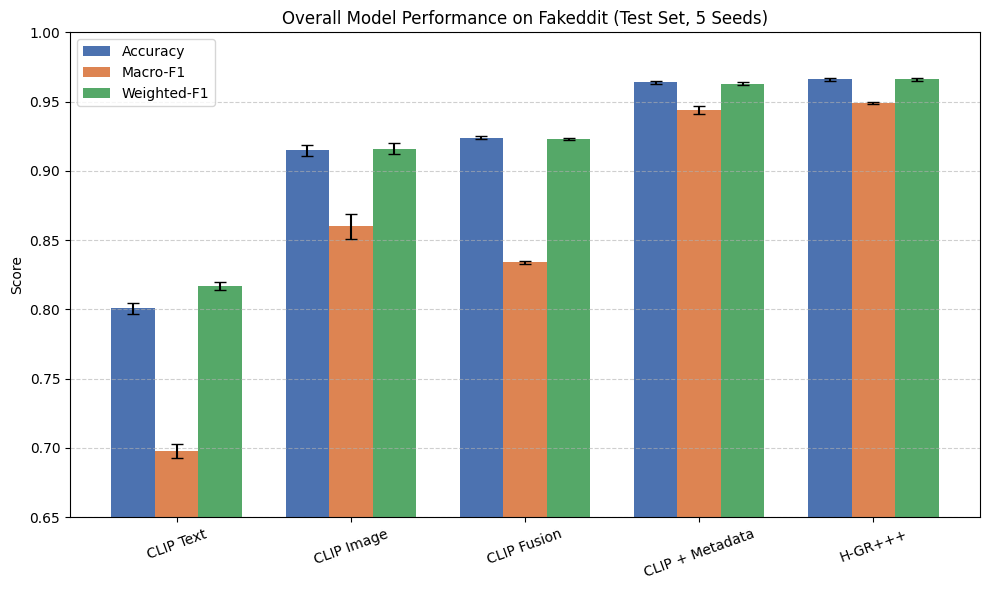

In [5]:

import matplotlib.pyplot as plt
import numpy as np

# Models
models = [
    "CLIP Text",
    "CLIP Image",
    "CLIP Fusion",
    "CLIP + Metadata",
    "H-GR+++"
]

# Mean values
accuracy = [0.801, 0.915, 0.924, 0.964, 0.966]
macro_f1 = [0.698, 0.860, 0.834, 0.944, 0.949]
weighted_f1 = [0.817, 0.916, 0.923, 0.963, 0.966]

# Standard deviations
acc_std = [0.004, 0.004, 0.001, 0.001, 0.001]
macro_std = [0.005, 0.009, 0.001, 0.003, 0.001]
weight_std = [0.003, 0.004, 0.001, 0.001, 0.001]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, accuracy, width, yerr=acc_std, capsize=4, label="Accuracy", color="#4C72B0")
plt.bar(x, macro_f1, width, yerr=macro_std, capsize=4, label="Macro-F1", color="#DD8452")
plt.bar(x + width, weighted_f1, width, yerr=weight_std, capsize=4, label="Weighted-F1", color="#55A868")

plt.xticks(x, models, rotation=20)
plt.ylabel("Score")
plt.title("Overall Model Performance on Fakeddit (Test Set, 5 Seeds)")
plt.ylim(0.65, 1.0)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()

# Save the figure 
plt.savefig("Overall Model Performance on Fakeddit (Test Set, 5 Seeds).png", dpi=300)
plt.savefig("Overall Model Performance on Fakeddit (Test Set, 5 Seeds).pdf")

plt.show()

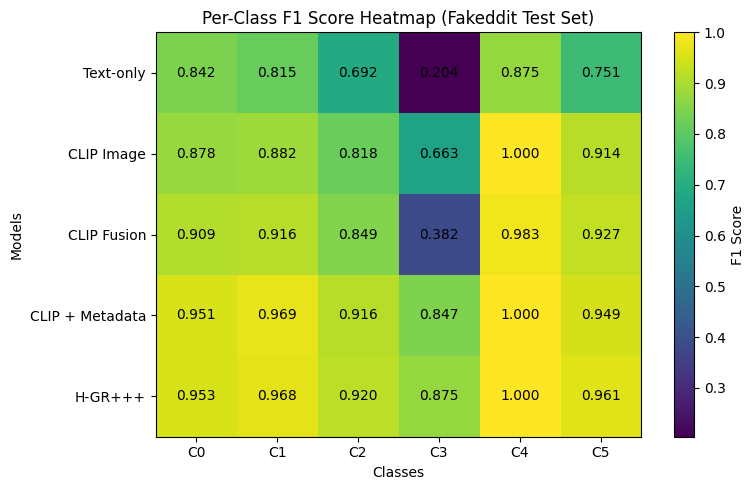

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Models
models = [
    "Text-only",
    "CLIP Image",
    "CLIP Fusion",
    "CLIP + Metadata",
    "H-GR+++"
]

# Classes
classes = ["C0", "C1", "C2", "C3", "C4", "C5"]

# Per-class F1 scores 
data = np.array([
    [0.842, 0.815, 0.692, 0.204, 0.875, 0.751],  # Text-only
    [0.878, 0.882, 0.818, 0.663, 1.000, 0.914],  # CLIP Image
    [0.909, 0.916, 0.849, 0.382, 0.983, 0.927],  # CLIP Fusion
    [0.951, 0.969, 0.916, 0.847, 1.000, 0.949],  # CLIP + Metadata
    [0.953, 0.968, 0.920, 0.875, 1.000, 0.961]   # H-GR+++
])

plt.figure(figsize=(8,5))

im = plt.imshow(data)

plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(models)), models)

plt.xlabel("Classes")
plt.ylabel("Models")
plt.title("Per-Class F1 Score Heatmap (Fakeddit Test Set)")

# Annotate values inside cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i, f"{data[i,j]:.3f}",
                 ha="center", va="center")

plt.colorbar(im, label="F1 Score")

plt.tight_layout()

# Save figure
plt.savefig("per_class_f1_heatmap.png", dpi=300)
plt.savefig("per_class_f1_heatmap.pdf")

plt.show()

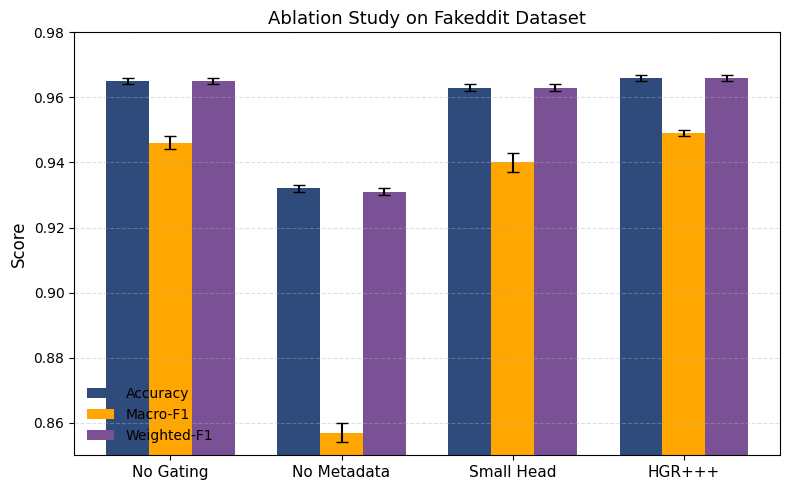

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data from ablation table
models = ["No Gating", "No Metadata", "Small Head", "HGR+++"]

accuracy = [0.965, 0.932, 0.963, 0.966]
macro_f1 = [0.946, 0.857, 0.940, 0.949]
weighted_f1 = [0.965, 0.931, 0.963, 0.966]

# Standard deviations
acc_std = [0.001, 0.001, 0.001, 0.001]
macro_std = [0.002, 0.003, 0.003, 0.001]
wf1_std = [0.001, 0.001, 0.001, 0.001]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))


colors = ["#2F4B7C", "#FFA600", "#7A5195"]

plt.bar(x - width, accuracy, width,
        yerr=acc_std,
        capsize=4,
        label="Accuracy",
        color=colors[0])

plt.bar(x, macro_f1, width,
        yerr=macro_std,
        capsize=4,
        label="Macro-F1",
        color=colors[1])

plt.bar(x + width, weighted_f1, width,
        yerr=wf1_std,
        capsize=4,
        label="Weighted-F1",
        color=colors[2])

plt.xticks(x, models, fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.title("Ablation Study on Fakeddit Dataset", fontsize=13)

plt.ylim(0.85, 0.98)


plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(frameon=False)

plt.tight_layout()


plt.savefig("ablation_barplot_q1.png", dpi=600, bbox_inches='tight')

plt.show()

# H-GR+++ Training, Evaluation, and Efficiency Analysis

In [1]:
# ============================================================
# TRAIN/VAL/TEST + PARAM COUNT + TRAIN TIME + INFERENCE SPEED
# An other run of IDENTICAL H-GR+++ on PRECOMPUTED FEATURES
#   - For Efficiency Analysis
# ============================================================

import os, time, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# -----------------------------
# CONFIG 
# -----------------------------
HGR10_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HGR10_NUM_LABELS = 6
HGR10_EPOCHS     = 6

HGR10_BATCH_TRAIN = 128
HGR10_BATCH_EVAL  = 256

HGR10_GRAD_CLIP_N   = 1.0
HGR10_LR_HEAD       = 2e-4
HGR10_WEIGHT_DECAY  = 1e-4
HGR10_LABEL_SMOOTH  = 0.02

HGR10_META_HIDDEN   = 256
HGR10_EMB_DIM       = 32
HGR10_GATE_HIDDEN   = 256
HGR10_HEAD_HIDDEN   = 1024
HGR10_DROPOUT       = 0.20
HGR10_GATE_TAU      = 2.0
HGR10_GATE_LAMBDA   = 0.005
HGR10_GATE_TARGET_M = 0.6

# Column semantics
HGR10_NUM_COLS = ["score", "num_comments", "upvote_ratio"]
HGR10_CAT_COLS = ["domain"]

FEAT_DIR = "/kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features"

print("Device:", HGR10_DEVICE)
print("FEAT_DIR:", FEAT_DIR)

# -----------------------------
# Load tensors
# -----------------------------
def load_split(name):
    t   = torch.load(os.path.join(FEAT_DIR, f"{name}_text.pt"))
    v   = torch.load(os.path.join(FEAT_DIR, f"{name}_image.pt"))
    y   = torch.load(os.path.join(FEAT_DIR, f"{name}_labels.pt"))
    num = torch.load(os.path.join(FEAT_DIR, f"{name}_num.pt"))
    has = torch.load(os.path.join(FEAT_DIR, f"{name}_has.pt"))
    cat = torch.load(os.path.join(FEAT_DIR, f"{name}_cat.pt"))
    return t, v, y, num, has, cat

train_t, train_v, train_y, train_num, train_has, train_cat = load_split("train")
val_t,   val_v,   val_y,   val_num,   val_has,   val_cat   = load_split("val")
test_t,  test_v,  test_y,  test_num,  test_has,  test_cat  = load_split("test")

print("\n✅ Loaded features:")
print("Train:", train_t.shape, train_v.shape, train_num.shape, train_has.shape, train_cat.shape, train_y.shape)
print("Val  :", val_t.shape,   val_v.shape,   val_num.shape,   val_has.shape,   val_cat.shape,   val_y.shape)
print("Test :", test_t.shape,  test_v.shape,  test_num.shape,  test_has.shape,  test_cat.shape,  test_y.shape)

# -----------------------------
# Force shapes + dtypes
# -----------------------------
def ensure_2d(x):
    return x.view(-1, 1) if x.ndim == 1 else x

train_cat = ensure_2d(train_cat).long()
val_cat   = ensure_2d(val_cat).long()
test_cat  = ensure_2d(test_cat).long()

train_has = ensure_2d(train_has).float()
val_has   = ensure_2d(val_has).float()
test_has  = ensure_2d(test_has).float()

train_num = train_num.float()
val_num   = val_num.float()
test_num  = test_num.float()

train_y = train_y.long()
val_y   = val_y.long()
test_y  = test_y.long()

# -----------------------------
# cat_sizes computed from ALL splits
# -----------------------------
if len(HGR10_CAT_COLS) > 0:
    C = train_cat.size(1)
    cat_sizes = []
    for i in range(C):
        mx = torch.cat([train_cat[:, i], val_cat[:, i], test_cat[:, i]]).max().item()
        cat_sizes.append(int(mx) + 1)
else:
    cat_sizes = []

print("\n✅ cat_sizes:", cat_sizes)
print("✅ cat shapes:", train_cat.shape, val_cat.shape, test_cat.shape)
print("✅ has shapes:", train_has.shape, val_has.shape, test_has.shape)

# -----------------------------
# Dataset
# -----------------------------
class HGRFeatDataset(Dataset):
    def __init__(self, t, v, y, num, has, cat):
        self.t = t
        self.v = v
        self.y = y
        self.num = num
        self.has = has
        self.cat = cat

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return {
            "t": self.t[i],
            "v": self.v[i],
            "labels": self.y[i],
            "num": self.num[i],
            "has_img": self.has[i],
            "cat_ids": self.cat[i],
        }

def collate(batch):
    t = torch.stack([b["t"] for b in batch])
    v = torch.stack([b["v"] for b in batch])
    num = torch.stack([b["num"] for b in batch]).float()
    has_img = torch.stack([b["has_img"] for b in batch]).float()
    labels = torch.stack([b["labels"] for b in batch]).long()

    if len(HGR10_CAT_COLS) > 0:
        cat_ids = torch.stack([b["cat_ids"] for b in batch]).long()
        if cat_ids.ndim == 1:
            cat_ids = cat_ids.view(-1, 1)
    else:
        cat_ids = torch.zeros((len(batch), 0), dtype=torch.long)

    return {"t": t, "v": v, "labels": labels, "num": num, "has_img": has_img, "cat_ids": cat_ids}

train_loader = DataLoader(
    HGRFeatDataset(train_t, train_v, train_y, train_num, train_has, train_cat),
    batch_size=HGR10_BATCH_TRAIN, shuffle=True, collate_fn=collate, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    HGRFeatDataset(val_t, val_v, val_y, val_num, val_has, val_cat),
    batch_size=HGR10_BATCH_EVAL, shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    HGRFeatDataset(test_t, test_v, test_y, test_num, test_has, test_cat),
    batch_size=HGR10_BATCH_EVAL, shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True
)

# -----------------------------
#  H-GR+++ (fusion/gate/head) 
# -----------------------------
class HGR10_HGR_Improved_Feats(nn.Module):
    def __init__(self, num_labels=6,
                 meta_hidden=256, emb_dim=32,
                 gate_hidden=256, head_hidden=1024,
                 dropout=0.20, gate_tau=2.0):
        super().__init__()
        self.gate_tau = gate_tau

        d = train_t.size(1)      # usually 512
        clip_dim = 2 * d         # usually 1024

        self.cat_embs = nn.ModuleList([
            nn.Embedding(cat_sizes[i], emb_dim) for i in range(len(HGR10_CAT_COLS))
        ])

        self.clip_compress = nn.Sequential(
            nn.Linear(clip_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        meta_in = len(HGR10_NUM_COLS) + 1 + len(HGR10_CAT_COLS) * emb_dim + 128
        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_in, meta_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.fused_dim = clip_dim + meta_hidden

        self.gate_logits = nn.Sequential(
            nn.Linear(meta_hidden, gate_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gate_hidden, self.fused_dim)
        )

        self.head = nn.Sequential(
            nn.Linear(self.fused_dim, head_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, num_labels)
        )

    def forward(self, t, v, num, has_img, cat_ids, return_gate=False):
        t = F.normalize(t, p=2, dim=1)
        v = F.normalize(v, p=2, dim=1)
        z_clip = torch.cat([t, v], dim=1)

        z_clip_comp = self.clip_compress(z_clip)

        if len(HGR10_CAT_COLS) > 0:
            cat = torch.cat([emb(cat_ids[:, i]) for i, emb in enumerate(self.cat_embs)], dim=1)
        else:
            cat = torch.empty((num.size(0), 0), device=num.device)

        meta_in = torch.cat([num, has_img, cat, z_clip_comp], dim=1)
        meta = self.meta_mlp(meta_in)

        z0 = torch.cat([z_clip, meta], dim=1)

        gl = self.gate_logits(meta)
        gate = torch.sigmoid(gl / self.gate_tau)

        z = z0 + z0 * (gate - 0.5)
        logits = self.head(z)

        if return_gate:
            return logits, gate
        return logits

model = HGR10_HGR_Improved_Feats(
    num_labels=HGR10_NUM_LABELS,
    meta_hidden=HGR10_META_HIDDEN,
    emb_dim=HGR10_EMB_DIM,
    gate_hidden=HGR10_GATE_HIDDEN,
    head_hidden=HGR10_HEAD_HIDDEN,
    dropout=HGR10_DROPOUT,
    gate_tau=HGR10_GATE_TAU
).to(HGR10_DEVICE)

# -----------------------------
# Parameter Count
# -----------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n=== MODEL COMPLEXITY ===")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable parameters (Millions): {trainable_params/1e6:.3f} M")

# -----------------------------
# Loss: Label smoothing + class weights
# -----------------------------
class HGR10_LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=HGR10_LABEL_SMOOTH, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        n_classes = logits.size(-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            if self.weight is not None:
                true_dist = true_dist * self.weight.view(1, -1)
                true_dist = true_dist / true_dist.sum(dim=1, keepdim=True)
        return -(true_dist * log_probs).sum(dim=1).mean()

counts = torch.bincount(train_y, minlength=HGR10_NUM_LABELS).cpu().numpy()
w = counts.sum() / (HGR10_NUM_LABELS * np.maximum(counts, 1))
class_weights = torch.tensor(w, dtype=torch.float, device=HGR10_DEVICE)
ce_loss = HGR10_LabelSmoothingCE(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=HGR10_LR_HEAD,
    weight_decay=HGR10_WEIGHT_DECAY
)

# -----------------------------
# Eval
# -----------------------------
@torch.no_grad()
def eval_model(m, loader):
    m.eval()
    yp, yt = [], []
    for b in loader:
        logits = m(
            b["t"].to(HGR10_DEVICE, non_blocking=True),
            b["v"].to(HGR10_DEVICE, non_blocking=True),
            b["num"].to(HGR10_DEVICE, non_blocking=True),
            b["has_img"].to(HGR10_DEVICE, non_blocking=True),
            b["cat_ids"].to(HGR10_DEVICE, non_blocking=True),
        )
        yp.append(logits.argmax(1).cpu())
        yt.append(b["labels"].cpu())
    y_pred = torch.cat(yp).numpy()
    y_true = torch.cat(yt).numpy()
    return (
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
        y_true, y_pred
    )

# -----------------------------
# Train
# -----------------------------
best_val_macro = -1.0
best_state = None
epoch_times = []

train_start_time = time.time()

for epoch in range(HGR10_EPOCHS):
    epoch_start = time.time()

    model.train()
    total_loss = 0.0
    gate_means = []

    for b in train_loader:
        logits, gate = model(
            b["t"].to(HGR10_DEVICE, non_blocking=True),
            b["v"].to(HGR10_DEVICE, non_blocking=True),
            b["num"].to(HGR10_DEVICE, non_blocking=True),
            b["has_img"].to(HGR10_DEVICE, non_blocking=True),
            b["cat_ids"].to(HGR10_DEVICE, non_blocking=True),
            return_gate=True
        )
        labels = b["labels"].to(HGR10_DEVICE, non_blocking=True)

        loss = ce_loss(logits, labels)
        gmean = gate.mean()
        loss = loss + HGR10_GATE_LAMBDA * (gmean - HGR10_GATE_TARGET_M).abs()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), HGR10_GRAD_CLIP_N)
        optimizer.step()

        total_loss += float(loss.item())
        gate_means.append(float(gmean.detach().item()))

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    val_acc, val_macro, val_wf1, _, _ = eval_model(model, val_loader)
    print(
        f"Epoch {epoch+1}/{HGR10_EPOCHS} | "
        f"train_loss={total_loss/len(train_loader):.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_macroF1={val_macro:.4f} | "
        f"val_weightedF1={val_wf1:.4f} | "
        f"gate_mean(train)={float(np.mean(gate_means)):.3f} | "
        f"epoch_time={epoch_time:.2f}s"
    )

    if val_macro > best_val_macro:
        best_val_macro = val_macro
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

total_training_time = time.time() - train_start_time

if best_state is not None:
    model.load_state_dict(best_state)

print("\n=== TRAINING TIME ===")
print(f"Total training time: {total_training_time:.2f} sec")
print(f"Total training time: {total_training_time/60:.2f} min")
print(f"Average epoch time: {np.mean(epoch_times):.2f} sec")
print(f"Best validation Macro-F1: {best_val_macro:.4f}")

# -----------------------------
# TEST
# -----------------------------
test_acc, test_macro, test_wf1, y_true, y_pred = eval_model(model, test_loader)

print("\n=== TEST (IDENTICAL H-GR+++ on precomputed CLIP) ===")
print(f"Acc: {test_acc:.4f}")
print(f"Macro-F1: {test_macro:.4f}")
print(f"Weighted-F1: {test_wf1:.4f}\n")

print("=== Per-class report (TEST) ===")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

print("=== Confusion matrix (TEST) ===")
print(confusion_matrix(y_true, y_pred))

# -----------------------------
# SANITY CHECK
# -----------------------------
rng = np.random.default_rng(0)
y_shuf = rng.permutation(y_true)
print("\n=== SANITY CHECK (should drop a lot) ===")
print("Macro-F1 real: ", f1_score(y_true, y_pred, average="macro"))
print("Macro-F1 shuf: ", f1_score(y_shuf, y_pred, average="macro"))

# -----------------------------
# Inference Speed
# -----------------------------
model.eval()

# warmup
with torch.no_grad():
    for i, b in enumerate(test_loader):
        if i >= 5:
            break
        _ = model(
            b["t"].to(HGR10_DEVICE, non_blocking=True),
            b["v"].to(HGR10_DEVICE, non_blocking=True),
            b["num"].to(HGR10_DEVICE, non_blocking=True),
            b["has_img"].to(HGR10_DEVICE, non_blocking=True),
            b["cat_ids"].to(HGR10_DEVICE, non_blocking=True),
        )

if torch.cuda.is_available():
    torch.cuda.synchronize()

start_inf = time.time()
num_samples = 0

with torch.no_grad():
    for b in test_loader:
        _ = model(
            b["t"].to(HGR10_DEVICE, non_blocking=True),
            b["v"].to(HGR10_DEVICE, non_blocking=True),
            b["num"].to(HGR10_DEVICE, non_blocking=True),
            b["has_img"].to(HGR10_DEVICE, non_blocking=True),
            b["cat_ids"].to(HGR10_DEVICE, non_blocking=True),
        )
        num_samples += b["t"].size(0)

if torch.cuda.is_available():
    torch.cuda.synchronize()

elapsed_inf = time.time() - start_inf
samples_per_sec = num_samples / elapsed_inf
latency_ms = (elapsed_inf / num_samples) * 1000.0

print("\n=== INFERENCE SPEED ===")
print(f"Total inference time: {elapsed_inf:.4f} sec")
print(f"Total samples: {num_samples}")
print(f"Samples/sec: {samples_per_sec:.2f}")
print(f"Latency per sample: {latency_ms:.4f} ms")

# -----------------------------
# Save best checkpoint
# -----------------------------
CKPT_OUT = "/kaggle/working/hgr_feats_best.pth"
torch.save(model.state_dict(), CKPT_OUT)
print("\n✅ Saved checkpoint:", CKPT_OUT)

# -----------------------------
# Final summary for paper
# -----------------------------
print("\n=== PAPER-READY EFFICIENCY SUMMARY ===")
print(f"Trainable Params (M): {trainable_params/1e6:.3f}")
print(f"Avg Epoch Time (sec): {np.mean(epoch_times):.2f}")
print(f"Inference Speed (samples/sec): {samples_per_sec:.2f}")
print(f"Latency (ms/sample): {latency_ms:.4f}")

Device: cuda
FEAT_DIR: /kaggle/input/datasets/rejuyanhossainshawon/fakeddit1-precomputed-features

✅ Loaded features:
Train: torch.Size([99200, 512]) torch.Size([99200, 512]) torch.Size([99200, 3]) torch.Size([99200, 1]) torch.Size([99200, 1]) torch.Size([99200])
Val  : torch.Size([12400, 512]) torch.Size([12400, 512]) torch.Size([12400, 3]) torch.Size([12400, 1]) torch.Size([12400, 1]) torch.Size([12400])
Test : torch.Size([12400, 512]) torch.Size([12400, 512]) torch.Size([12400, 3]) torch.Size([12400, 1]) torch.Size([12400, 1]) torch.Size([12400])

✅ cat_sizes: [1620]
✅ cat shapes: torch.Size([99200, 1]) torch.Size([12400, 1]) torch.Size([12400, 1])
✅ has shapes: torch.Size([99200, 1]) torch.Size([12400, 1]) torch.Size([12400, 1])

=== MODEL COMPLEXITY ===
Total parameters: 1,937,926
Trainable parameters: 1,937,926
Trainable parameters (Millions): 1.938 M
Epoch 1/6 | train_loss=0.7892 | val_acc=0.9503 | val_macroF1=0.8545 | val_weightedF1=0.9484 | gate_mean(train)=0.735 | epoch_time=